In [39]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")


import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [40]:
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'
fm.fontManager.addfont(font_path)  # Only if you're adding a new font file
fm._load_fontmanager(try_read_cache=False)

# HumanCT IQ Phenotype


In [41]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.1.Filt.Spec.clip.lowexp.cut1e4.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)

In [42]:
CogDF = pd.read_excel("../dat/41588_2023_1398_MOESM3_ESM.xlsx", sheet_name="Table S4")
CogDF = CogDF[CogDF["POPULATION"]=="EUR"]
for i, row in CogDF.iterrows():
    genesymbol = row["GENE"]
    if genesymbol in GeneSymbol2Entrez:
        CogDF.loc[i, "Entrez"] = GeneSymbol2Entrez[genesymbol]
    else:
        CogDF.loc[i, "Entrez"] = -1
CogDF = CogDF[CogDF["Entrez"] != -1]
# Entrez contert to int 
CogDF["Entrez"] = CogDF["Entrez"].astype(int)


In [43]:
VNR_DF = CogDF[CogDF["PHENOTYPE"]=="VNR"]
VNR_DF = VNR_DF[VNR_DF["Entrez"]!=-1]

RT_DF = CogDF[CogDF["PHENOTYPE"]=="RT"]
RT_DF = RT_DF[RT_DF["Entrez"]!=-1]

EDU_DF = CogDF[CogDF["PHENOTYPE"]=="EDU"]
EDU_DF = EDU_DF[EDU_DF["Entrez"]!=-1]

In [44]:
from scipy.stats import spearmanr

def BiasVsPheno_UKBB(MutPhenoDF, BiasMat, STR, label):
    biases = []
    IQs = []
    for i, row in MutPhenoDF.iterrows():
        if label == 'label':
            gene = row["HGNC"]
        else:
            gene = int(row["Entrez"])
        if gene in BiasMat.index.values:
            bias = BiasMat.loc[gene, STR]
            if bias == bias:
                IQ = row["BETA"]
                biases.append(bias)
                IQs.append(IQ)
    return biases, IQs

def Plot_Bias_vs_UKBBPheno(STR, Mut_n_IQ_conf, ylabel, HCT_Z2_MAT_HCT = HumanCT_Z2_HCT):
    biases, IQs = BiasVsPheno_UKBB(Mut_n_IQ_conf, HCT_Z2_MAT_HCT , STR, 'XX')
    pho, p = spearmanr(biases, IQs)
    plt.figure(dpi=150, figsize=(5, 4))
    plt.scatter(biases, IQs, s=50, color="#2c7bb6", edgecolor="black", alpha=0.8, zorder=10)

    b, a = np.polyfit(biases, IQs, deg=1)
    xseq = np.linspace(min(biases), max(biases), num=100)
    plt.plot(xseq, a + b * xseq, color="#d7191c", lw=2.5, linestyle='--', zorder=5)
    _SuperCluster = Anno.loc[STR, "Supercluster"]
    # Add title with improved formatting
    plt.title(f'{_SuperCluster} - {STR} \nSpearman ρ = {pho:.2f}, p = {p:.2e}', fontsize=14, fontweight='bold')

    # Labeling axes
    plt.xlabel("Cell Type Bias", fontsize=12, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12, fontweight='bold')

    # Grid lines for better readability
    plt.grid(True, linestyle='--', alpha=0.5)

    # Adjust tick parameters
    plt.xticks(fontsize=10, fontweight='bold')
    plt.yticks(fontsize=10, fontweight='bold')

    # Tight layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

In [45]:
VNR_DF_highConf = VNR_DF[VNR_DF["P"]<0.05]
VNR_DF_highConf_Pos = VNR_DF_highConf[VNR_DF_highConf["BETA"]>0]
VNR_DF_highConf_Neg = VNR_DF_highConf[VNR_DF_highConf["BETA"]<0]

In [77]:
#VNR_DF_highConf = VNR_DF[VNR_DF["P"]<0.05]
VNR_DF_highConf = VNR_DF
VNR_DF_highConf_Pos = VNR_DF_highConf[VNR_DF_highConf["BETA"]>0]
VNR_DF_highConf_Neg = VNR_DF_highConf[VNR_DF_highConf["BETA"]<0]

In [78]:
Neuron_idx = Anno[Anno["Supercluster"].isin(Neurons)].index.values

In [79]:
from scipy.stats import pearsonr

def linear_fit(biases, IQs, alpha=0.05):
    model = sm.OLS(IQs, sm.add_constant(biases))
    results = model.fit()
    
    intercept = results.params[0]
    beta = results.params[1]
    # get CI of beta
    ci = results.conf_int(alpha=alpha)

    ci_low = ci[1][0]
    ci_high = ci[1][1]     
    r_value = results.rsquared
    p_value = results.pvalues[1]
    std_err = results.bse[1]
    rho, p_rho = spearmanr(biases, IQs)
    r, p_r = pearsonr(biases, IQs)
    
    return intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r

def Make_HumanCT_DF(Mut_n_IQ_conf, HCT_Z2_MAT_HCT, output_file=None, alpha=0.05):
    names, supercluster, spearmanr, spearmanp, pearsonr_list, pearsonp, beta_values, beta_ci_low, beta_ci_high, intercept_values, r_value_values, p_value_values, std_err_values = [],[],[],[],[],[],[],[],[],[],[],[],[]
    for Idx in HCT_Z2_MAT_HCT.columns.values:
        biases, IQs = BiasVsPheno_UKBB(Mut_n_IQ_conf, HCT_Z2_MAT_HCT , Idx, 'xx')
        intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r = linear_fit(biases, IQs, alpha=0.05)
        
        names.append("{}".format(Idx))
        supercluster.append(Anno.loc[Idx, "Supercluster"])
        spearmanr.append(rho)
        spearmanp.append(p_rho)
        pearsonr_list.append(r)
        pearsonp.append(p_r)
        beta_values.append(beta)
        beta_ci_low.append(ci_low)
        beta_ci_high.append(ci_high)
        intercept_values.append(intercept)
        r_value_values.append(r_value)
        p_value_values.append(p_value)
        std_err_values.append(std_err)

    str_res_df = pd.DataFrame(data={"CT":names, "Supercluster":supercluster, "SpearmanR":spearmanr, "SpearmanP":spearmanp, 
                                            "PearsonR":pearsonr_list, "PearsonP":pearsonp, "beta":beta_values, "CI_low":beta_ci_low, "CI_high":beta_ci_high, "intercept":intercept_values, "r_value":r_value_values, 
                                            "p_value":p_value_values, "std_err":std_err_values})
    str_res_df = str_res_df.sort_values("SpearmanR")
    #str_res_df = ADJ_P(str_res_df)
    if output_file is not None:
        str_res_df.to_csv(output_file)
    return str_res_df

#human_ct_res_df_mutL.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.mutL.csv")

In [80]:
VNR_DF_highConf_Neg.head(2)

,POPULATION,PHENOTYPE,GENE,BETA,SE,P,NSAMPLE,NCARRIER,Entrez
37201,EUR,VNR,NOC2L,-0.193551,0.116860,0.097669,159026,62,26155
37202,EUR,VNR,KLHL17,-0.069487,0.124067,0.575428,159026,55,339451


In [81]:
human_ct_df_VNR = Make_HumanCT_DF(VNR_DF_highConf, HumanCT_Z2_HCT)
human_ct_df_VNR_neg = Make_HumanCT_DF(VNR_DF_highConf_Neg, HumanCT_Z2_HCT)
human_ct_df_VNR_pos = Make_HumanCT_DF(VNR_DF_highConf_Pos, HumanCT_Z2_HCT)

In [82]:
human_ct_df_VNR.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
196,196,Hippocampal CA4,-0.069427,7.865903e-13,-0.065179,1.765768e-11,-0.028848,-0.037249,-0.020448,-0.002360,0.004248,1.765768e-11,0.004286
429,429,Splatter,-0.060209,5.281277e-10,-0.055617,9.686550e-09,-0.028291,-0.037952,-0.018631,0.002199,0.003093,9.686550e-09,0.004928
146,146,Deep-layer intratelencephalic,-0.059142,1.059241e-09,-0.055313,1.165801e-08,-0.026648,-0.035797,-0.017499,-0.002048,0.003059,1.165801e-08,0.004668
428,428,Splatter,-0.058935,1.210093e-09,-0.058522,1.577505e-09,-0.030811,-0.040808,-0.020814,0.004450,0.003425,1.577505e-09,0.005100
190,190,Hippocampal CA4,-0.058035,2.152639e-09,-0.054655,1.732971e-08,-0.023459,-0.031611,-0.015307,-0.003968,0.002987,1.732971e-08,0.004159
163,163,Hippocampal CA1-3,-0.057930,2.299797e-09,-0.056109,7.169419e-09,-0.025156,-0.033670,-0.016642,-0.001608,0.003148,7.169419e-09,0.004344
405,405,Amygdala excitatory,-0.057476,3.063333e-09,-0.056082,7.288812e-09,-0.028007,-0.037491,-0.018523,-0.000188,0.003145,7.288812e-09,0.004838
198,198,Hippocampal CA4,-0.057475,3.065497e-09,-0.052428,6.419821e-08,-0.023194,-0.031597,-0.014791,-0.004433,0.002749,6.419821e-08,0.004287
197,197,Hippocampal CA4,-0.056900,4.394251e-09,-0.055869,8.303966e-09,-0.025157,-0.033708,-0.016606,-0.003542,0.003121,8.303966e-09,0.004362
179,179,Hippocampal CA1-3,-0.056076,7.316351e-09,-0.056549,5.463342e-09,-0.024488,-0.032711,-0.016265,-0.003225,0.003198,5.463342e-09,0.004195


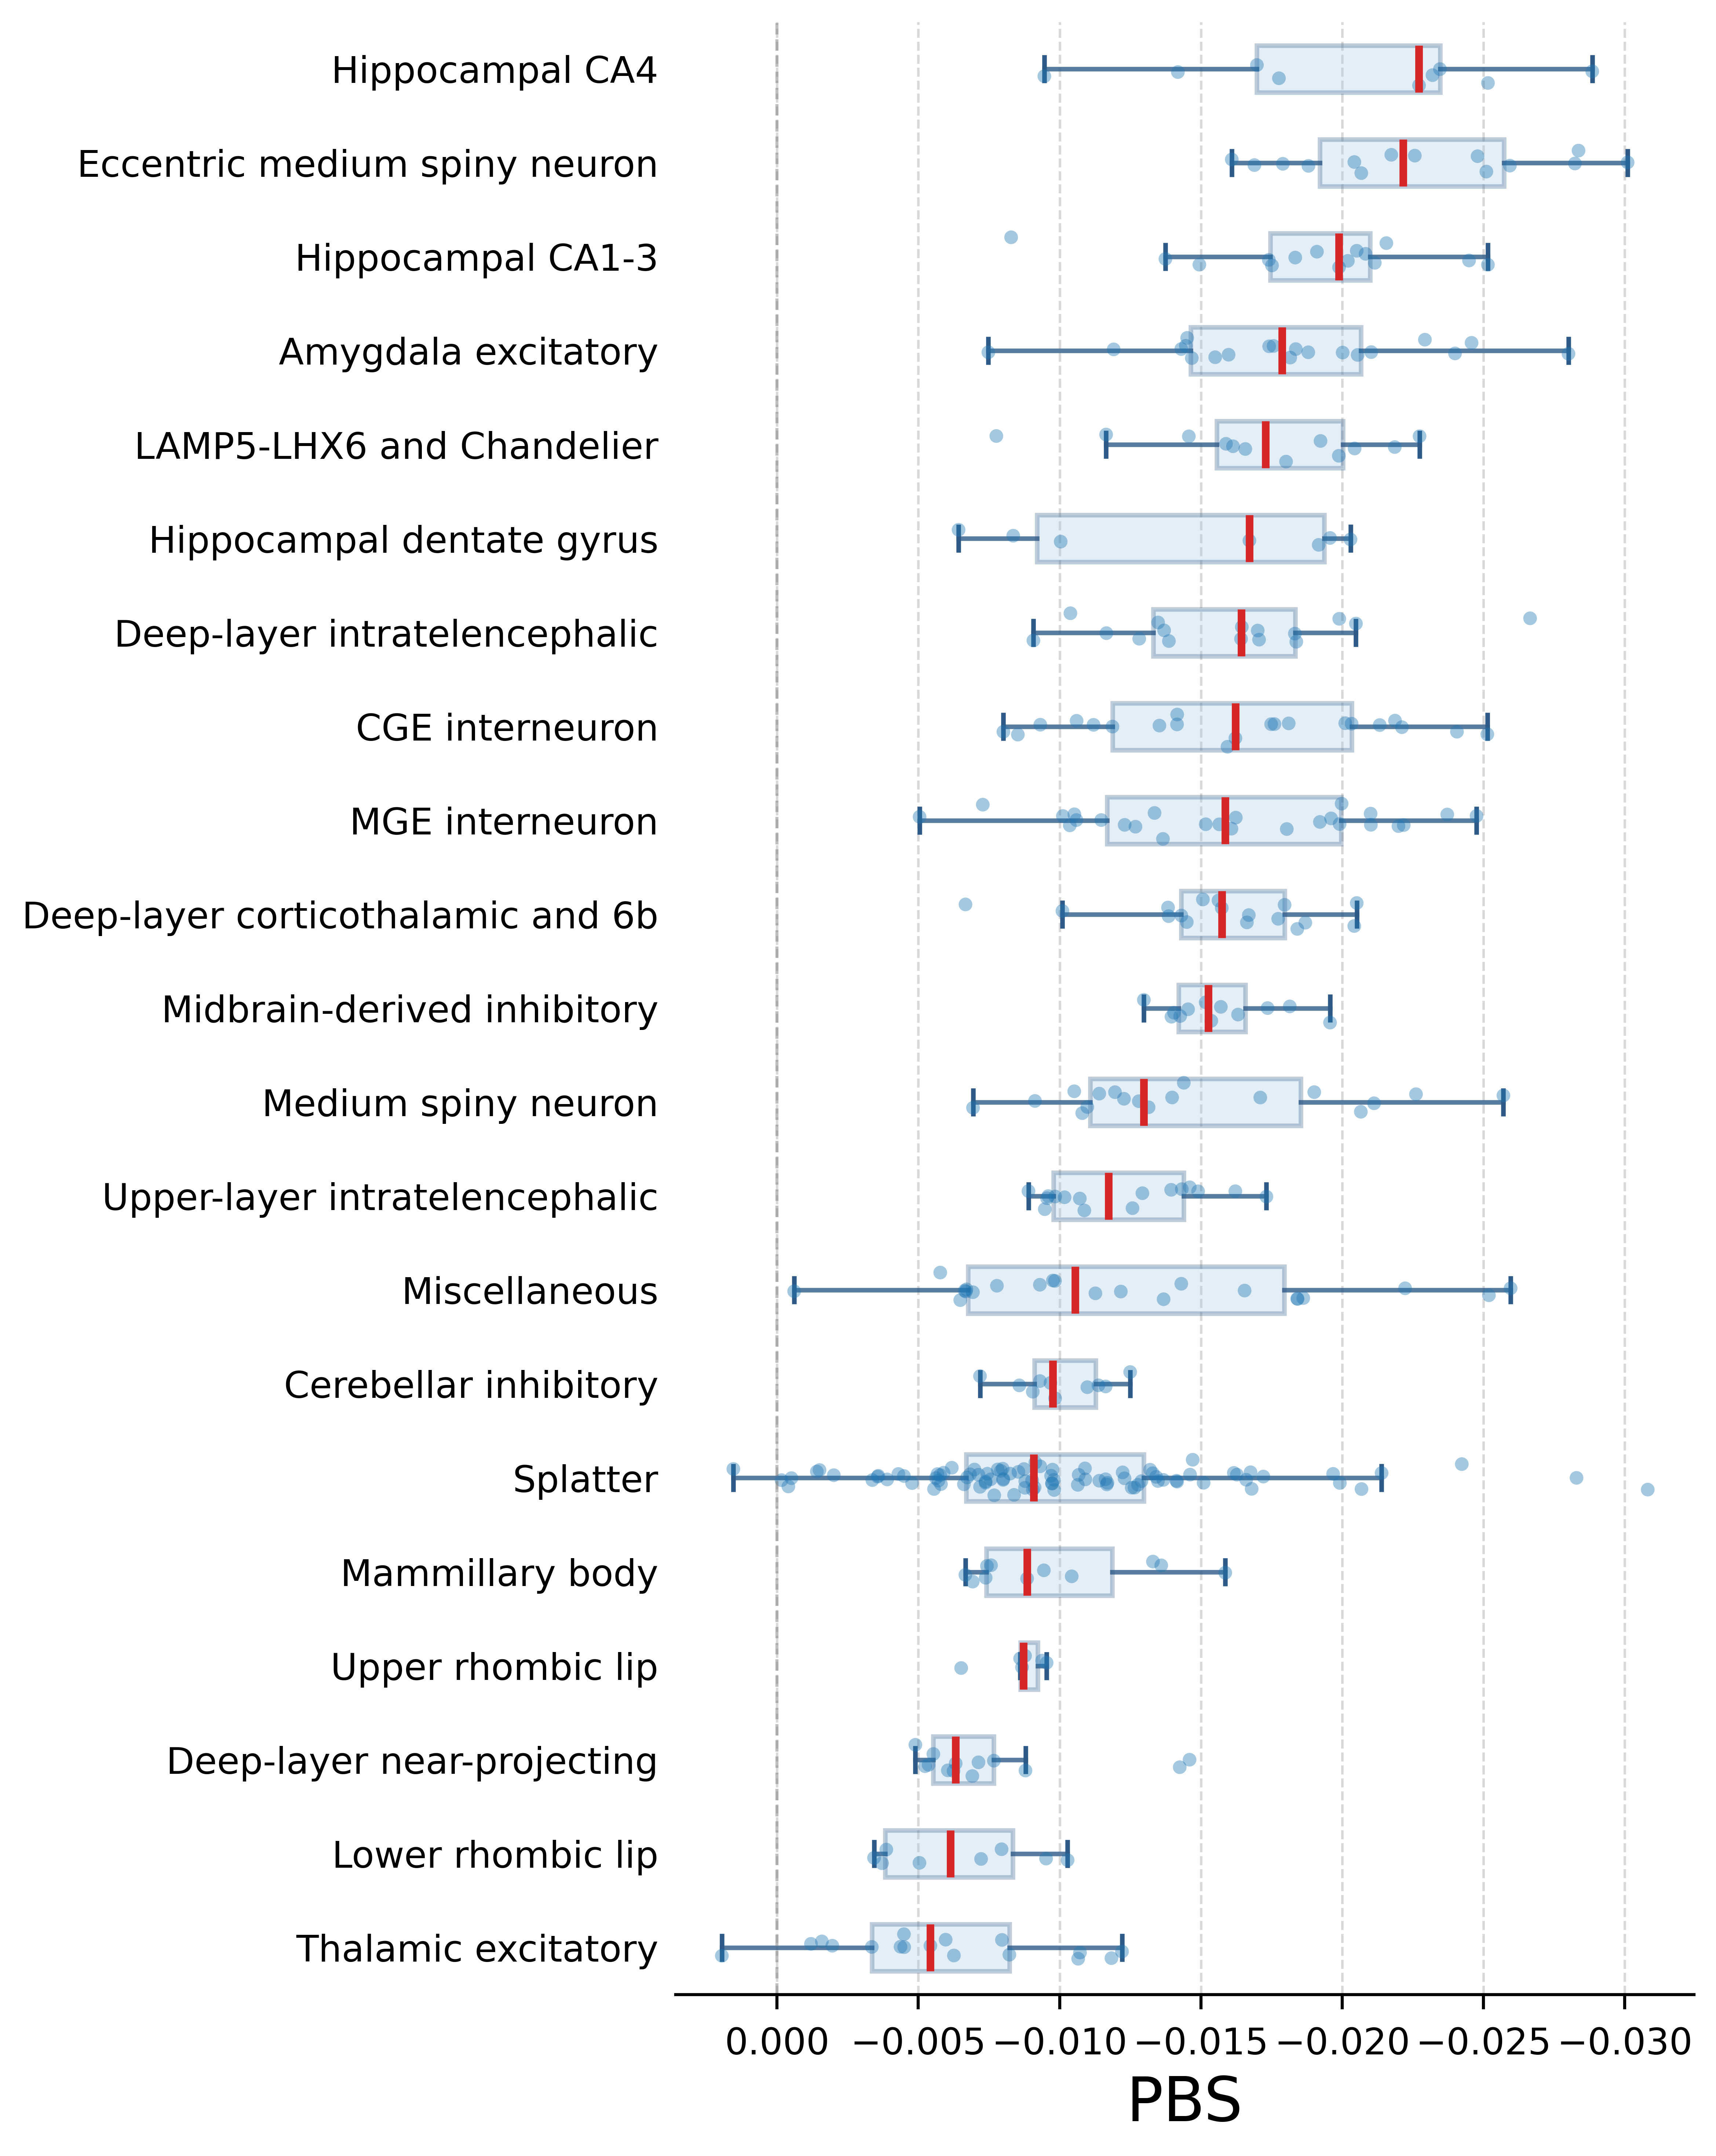

In [83]:
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR, "VNR Spec", plot_metric="beta", sortby="median")

In [84]:
# def SuperClusterBias_BoxPlot_CorrIQ(DF1, flip_axis=True, plot_metric="beta", figsize=(8, 10), xlabel="", sortby="mean", FDR_label="FDR", Pval_label="p_beta_perm_Log"):
#     # Prepare data
#     dat_Z2 = []
#     mean_Z2 = []
#     for _CT in Neurons:
#         tmp = DF1[DF1["Supercluster"] == _CT]
#         dat_Z2.append(tmp[plot_metric].values)
#         if sortby == "mean":
#             mean_Z2.append(np.mean(tmp[plot_metric].values))
#         elif sortby == "median":
#             mean_Z2.append(np.median(tmp[plot_metric].values))
#     mean_Z2 = np.array(mean_Z2)
#     # Sort data###
#     if flip_axis:
#         sort_idx = np.argsort(mean_Z2)[::-1]
#     else:
#         sort_idx = np.argsort(mean_Z2)
#     show_dat_Z2 = [dat_Z2[x] for x in sort_idx]
#     show_CTs = [ALL_CTs[x] for x in sort_idx]

#     # Set publication-quality style
#     plt.style.use('seaborn-v0_8-paper')
#     sns.set_context("paper", font_scale=1.4)
    
#     # Create figure
#     fig, ax = plt.subplots(dpi=600, figsize=figsize)

#     # Define colors and styles
#     box_color = '#2E5A88'  # Darker blue
#     point_color = '#1f77b4'  # Seaborn blue
    
#     # Customize boxplot appearance
#     boxprops = dict(linestyle='-', linewidth=1.5, color=box_color, alpha=0.8)
#     medianprops = dict(linestyle='-', linewidth=2.5, color='#D62728')  # Red median line
#     whiskerprops = dict(color=box_color, linewidth=1.5, alpha=0.8)
#     capprops = dict(color=box_color, linewidth=1.5)
#     flierprops = dict(marker='', color=box_color, alpha=0)  # Hide outliers

#     # Draw boxplot
#     bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,
#                     boxprops=boxprops, medianprops=medianprops,
#                     whiskerprops=whiskerprops, capprops=capprops, flierprops=flierprops)
    
#     # Fill boxes with lighter color
#     for patch in bp['boxes']:
#         patch.set_facecolor('#A8C8E4')  # Light blue
#         patch.set_alpha(0.3)

#     # Add individual points with jitter
#     for i in range(len(show_dat_Z2)):
#         y = np.random.normal(i + 1, 0.08, size=len(show_dat_Z2[i]))
#         ax.scatter(show_dat_Z2[i], y, s=20, color=point_color, alpha=0.4, 
#                   edgecolor='none', zorder=2)

#     # Customize grid
#     ax.grid(True, axis='x', linestyle='--', alpha=0.3, color='gray')
#     ax.grid(False, axis='y')

#     # Labels and title
#     if plot_metric == "beta":
#         ax.set_xlabel("PBS", fontsize=20, fontweight='normal')
#     elif plot_metric == "SpearmanR":
#         ax.set_xlabel("Spearman Correlation", fontsize=20, fontweight='normal')
#         #ax.set_ylabel("Superclusters", fontsize=20, fontweight='normal')
#     elif plot_metric == "p_beta_perm_Log" or plot_metric == "-log10(p)":
#         #ax.set_xlabel("PBS -log10(P)", fontsize=20, fontweight='normal')
#         ax.set_xlabel(xlabel, fontsize=20, fontweight='normal')
#         FDR_cut = GetFDRCut_PBS(DF1, FDR=0.05, FDR_label=FDR_label, Pval_label=Pval_label)
#         ax.axvline(x=FDR_cut, color='red', linestyle='--', linewidth=1, alpha=0.8)
#         #ax.text(FDR_cut, 0.95, "FDR=0.05", fontsize=12, fontweight='normal', ha='right', va='top', color='red', alpha=0.5)
#         ax.text(FDR_cut, 0.95, "FDR=0.05", fontsize=12, fontweight='normal', va='top', color='red', alpha=0.8)
#     else:
#         ax.set_xlabel(xlabel, fontsize=20, fontweight='normal')

#     # Customize axis appearance
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['left'].set_visible(False)
    
#     # Adjust tick parameters
#     ax.tick_params(axis='both', which='major', labelsize=12)
#     ax.tick_params(axis='y', length=0)  # Remove y-axis ticks
    
#     # Flip axis if needed
#     if flip_axis:
#         ax.invert_xaxis()
    
#     if plot_metric == "beta":
#         #ax.set_xlim(7.5, -10)
#         pass



#     # Add zero line
#     ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
#     plt.tight_layout()
#     plt.show()

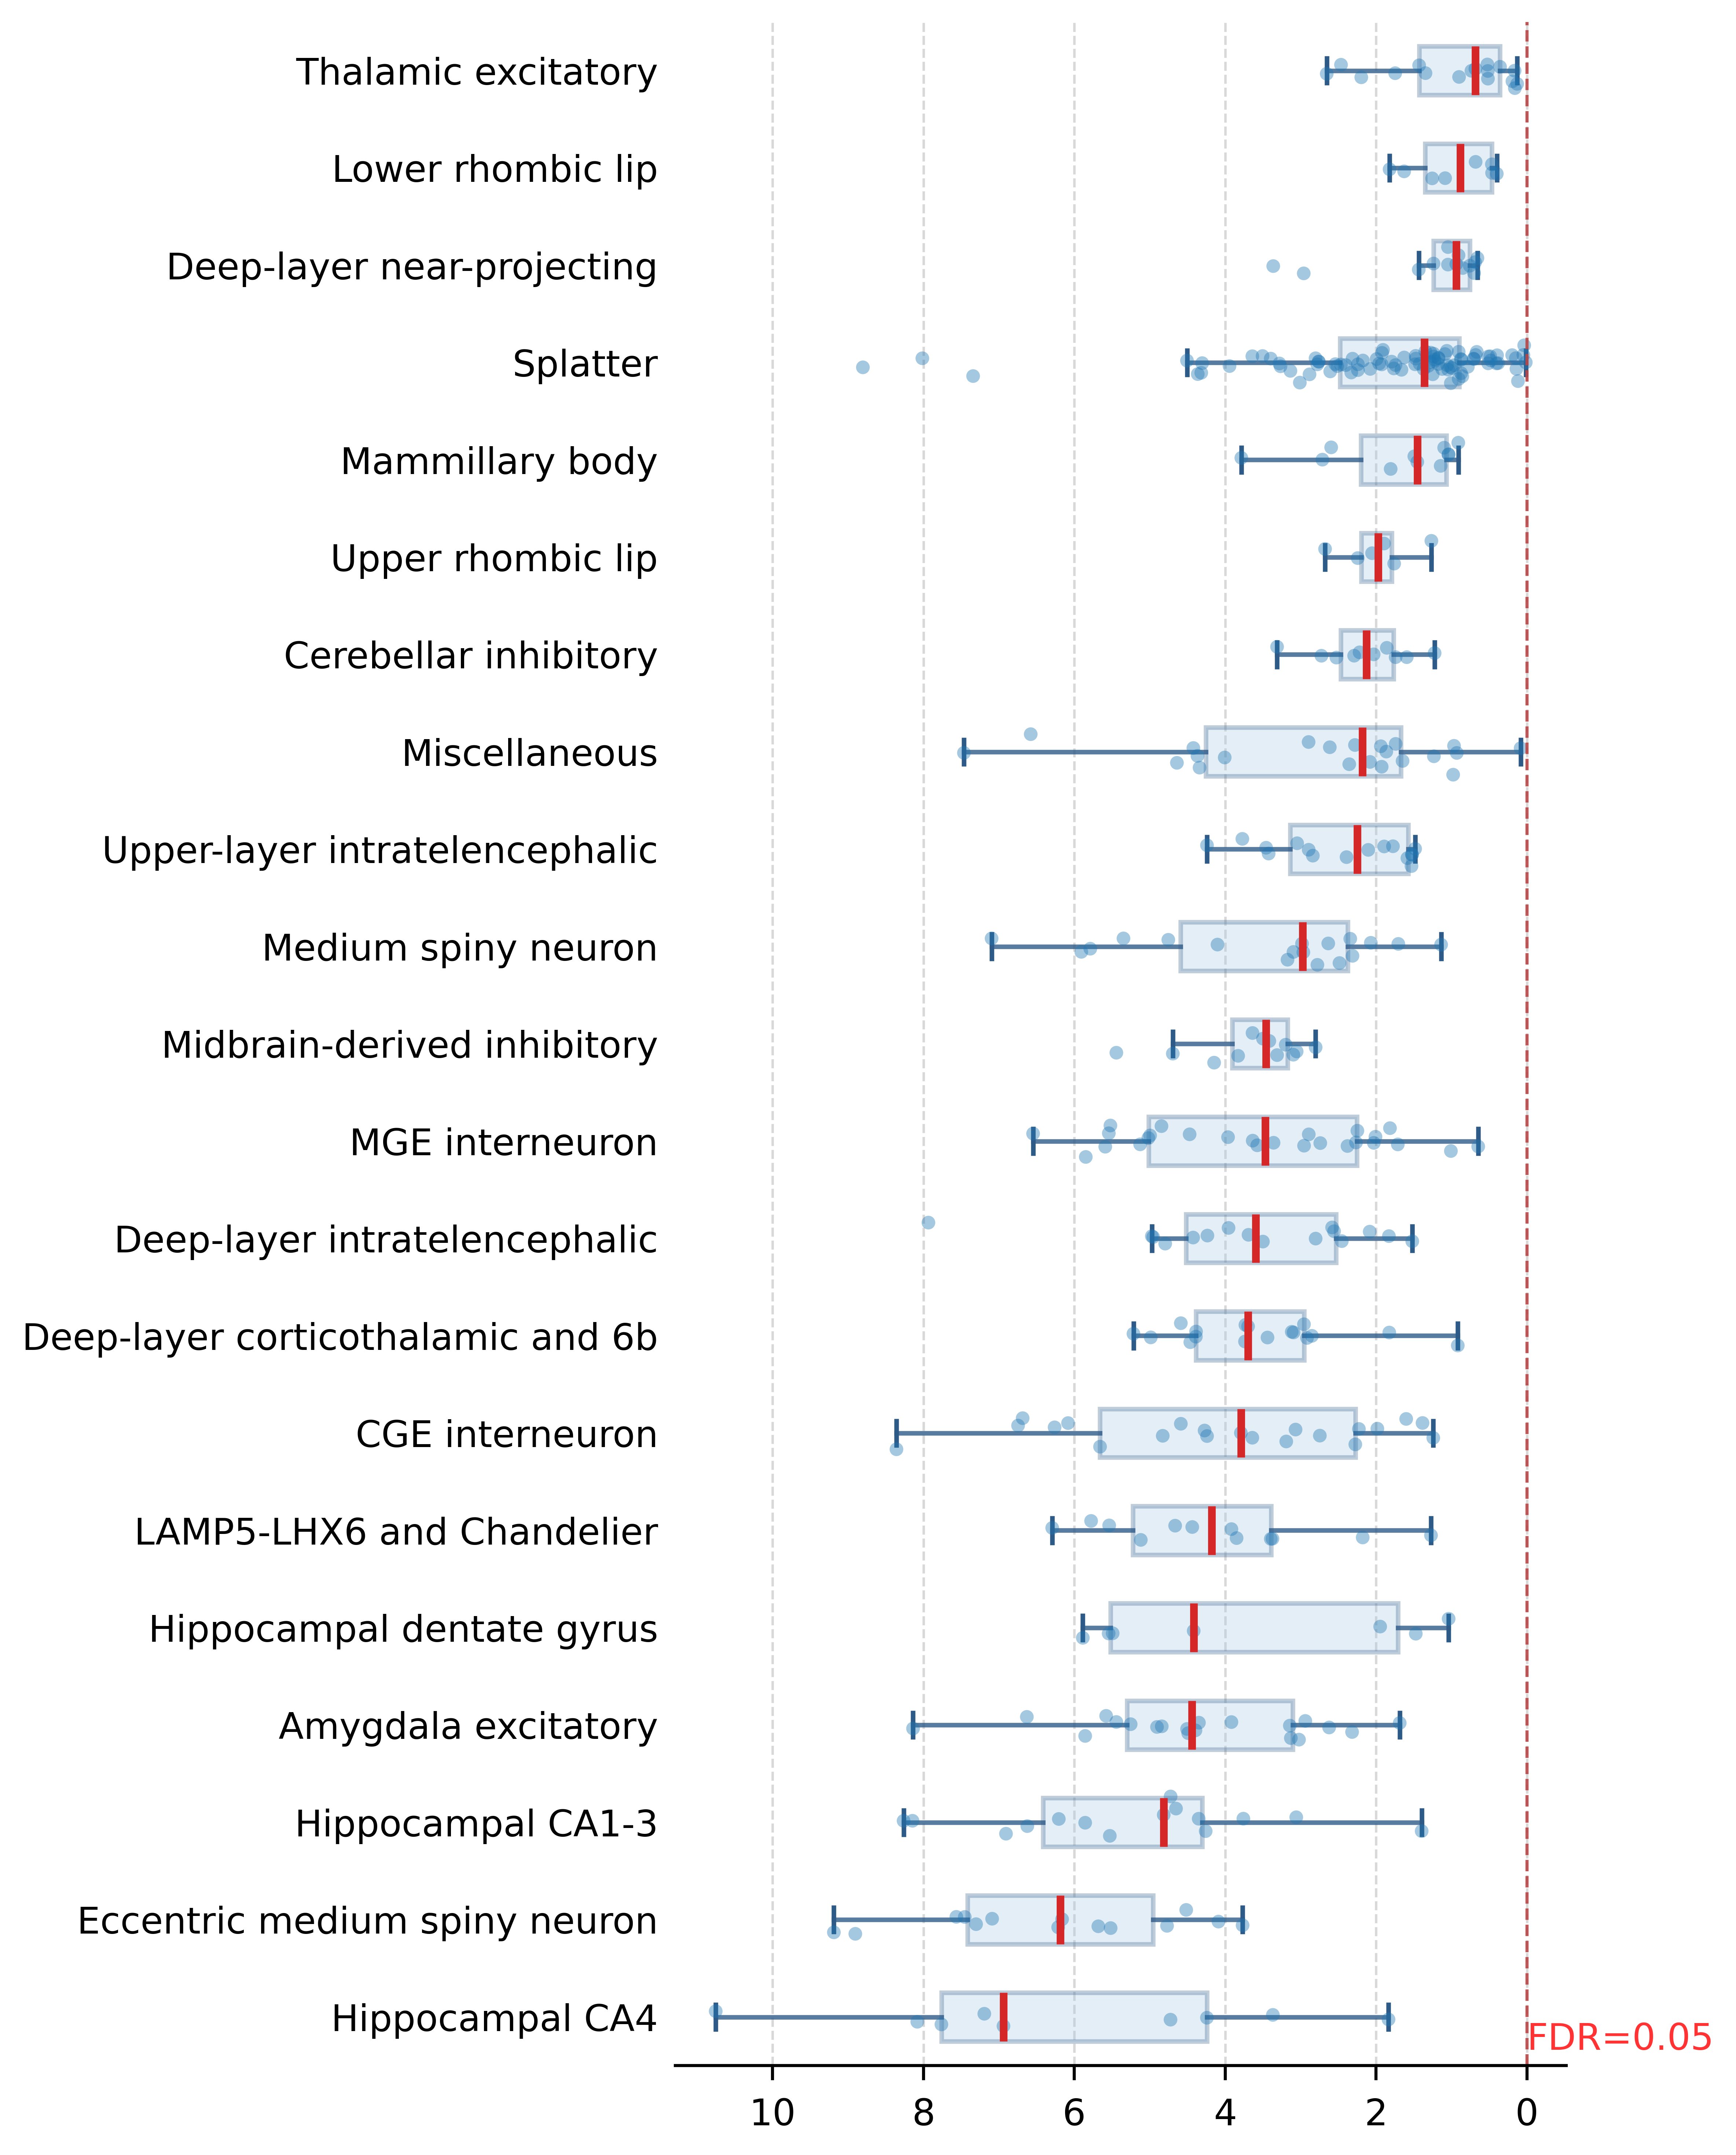

In [85]:
human_ct_df_VNR['-log10(p)'] = -np.log10(human_ct_df_VNR['p_value'])
human_ct_df_VNR["FDR"] = fdrcorrection(human_ct_df_VNR["p_value"])[1]
human_ct_df_VNR.head(20)
human_ct_df_VNR[human_ct_df_VNR["FDR"]<0.05].head(50)
human_ct_df_VNR.head(20)
human_ct_df_VNR['-log10(p)'] = -np.log10(human_ct_df_VNR['p_value'])
human_ct_df_VNR["FDR"] = fdrcorrection(human_ct_df_VNR["p_value"])[1]
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR, "VNR Spec", FDR_label="FDR", plot_metric="-log10(p)", sortby="median")

In [86]:
human_ct_df_VNR[human_ct_df_VNR["FDR"]<0.05]

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,-log10(p),FDR
196,196,Hippocampal CA4,-0.069427,7.865903e-13,-0.065179,1.765768e-11,-0.028848,-0.037249,-0.020448,-0.002360,0.004248,1.765768e-11,0.004286,10.753066,8.140191e-09
429,429,Splatter,-0.060209,5.281277e-10,-0.055617,9.686550e-09,-0.028291,-0.037952,-0.018631,0.002199,0.003093,9.686550e-09,0.004928,8.013831,4.465499e-07
146,146,Deep-layer intratelencephalic,-0.059142,1.059241e-09,-0.055313,1.165801e-08,-0.026648,-0.035797,-0.017499,-0.002048,0.003059,1.165801e-08,0.004668,7.933375,4.885767e-07
428,428,Splatter,-0.058935,1.210093e-09,-0.058522,1.577505e-09,-0.030811,-0.040808,-0.020814,0.004450,0.003425,1.577505e-09,0.005100,8.802029,1.818075e-07
190,190,Hippocampal CA4,-0.058035,2.152639e-09,-0.054655,1.732971e-08,-0.023459,-0.031611,-0.015307,-0.003968,0.002987,1.732971e-08,0.004159,7.761209,6.657498e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,140,Deep-layer intratelencephalic,-0.019637,4.298200e-02,-0.021023,3.025247e-02,-0.009072,-0.017278,-0.000866,-0.013667,0.000442,3.025247e-02,0.004186,1.519239,4.727589e-02
215,215,Medium spiny neuron,-0.019602,4.334906e-02,-0.022614,1.976601e-02,-0.009128,-0.016803,-0.001452,-0.013900,0.000511,1.976601e-02,0.003916,1.704081,3.231252e-02
130,130,Upper-layer intratelencephalic,-0.019543,4.399242e-02,-0.021115,2.953353e-02,-0.009555,-0.018161,-0.000950,-0.013128,0.000446,2.953353e-02,0.004390,1.529685,4.662657e-02
387,387,Splatter,-0.019540,4.402361e-02,-0.024267,1.237537e-02,-0.011403,-0.020338,-0.002468,-0.010828,0.000589,1.237537e-02,0.004558,1.907442,2.202721e-02


In [57]:
#SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR_neg, "VNR Spec Neg", plot_metric="beta")
#SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR_pos, "VNR Spec Pos", plot_metric="beta")

In [58]:
EDU_DF_highConf = EDU_DF[EDU_DF["P"]<0.05]
RT_DF_highConf = RT_DF[RT_DF["P"]<0.05]
EDU_DF_highConf_Pos = EDU_DF_highConf[EDU_DF_highConf["BETA"]>0]
EDU_DF_highConf_Neg = EDU_DF_highConf[EDU_DF_highConf["BETA"]<0]

RT_DF_highConf_Pos = RT_DF_highConf[RT_DF_highConf["BETA"]>0]
RT_DF_highConf_Neg = RT_DF_highConf[RT_DF_highConf["BETA"]<0]


human_ct_df_EDU = Make_HumanCT_DF(EDU_DF_highConf, HumanCT_Z2_HCT)
human_ct_df_EDU_neg = Make_HumanCT_DF(EDU_DF_highConf_Neg, HumanCT_Z2_HCT)
human_ct_df_EDU_pos = Make_HumanCT_DF(EDU_DF_highConf_Pos, HumanCT_Z2_HCT)

human_ct_df_RT = Make_HumanCT_DF(RT_DF_highConf, HumanCT_Z2_HCT)
human_ct_df_RT_neg = Make_HumanCT_DF(RT_DF_highConf_Neg, HumanCT_Z2_HCT)
human_ct_df_RT_pos = Make_HumanCT_DF(RT_DF_highConf_Pos, HumanCT_Z2_HCT)

#SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR_neg, "VNR Spec Neg", plot_metric="beta")
#SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR_pos, "VNR Spec Pos", plot_metric="beta")

In [59]:
human_ct_df_EDU["FDR"] = fdrcorrection(human_ct_df_EDU["p_value"])[1]
human_ct_df_VNR["FDR"] = fdrcorrection(human_ct_df_VNR["p_value"])[1]
human_ct_df_RT["FDR"] = fdrcorrection(human_ct_df_RT["p_value"])[1]

In [60]:
human_ct_df_EDU.head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,FDR
403,403,Splatter,-0.203741,4.475595e-09,-0.172424,7.461926e-07,-0.109879,-0.153119,-0.066640,-0.042181,0.029730,7.461926e-07,0.022028,0.000125
136,136,Deep-layer intratelencephalic,-0.203735,4.480501e-09,-0.190281,4.485911e-08,-0.117970,-0.159897,-0.076044,-0.043920,0.036207,4.485911e-08,0.021359,0.000021
242,242,MGE interneuron,-0.171207,8.947717e-07,-0.168053,1.423891e-06,-0.112066,-0.157348,-0.066784,-0.046379,0.028242,1.423891e-06,0.023069,0.000131
439,439,Midbrain-derived inhibitory,-0.166067,1.899323e-06,-0.140357,5.863227e-05,-0.086879,-0.129095,-0.044663,-0.066820,0.019700,5.863227e-05,0.021507,0.000932
280,280,CGE interneuron,-0.165721,1.996398e-06,-0.150475,1.624349e-05,-0.101862,-0.147962,-0.055763,-0.049614,0.022643,1.624349e-05,0.023485,0.000416
435,435,Midbrain-derived inhibitory,-0.165642,2.019449e-06,-0.153766,1.050320e-05,-0.094797,-0.136759,-0.052835,-0.063673,0.023644,1.050320e-05,0.021378,0.000354
296,296,CGE interneuron,-0.164318,2.441276e-06,-0.137226,8.575208e-05,-0.089289,-0.133686,-0.044892,-0.060184,0.018831,8.575208e-05,0.022618,0.001129
438,438,Midbrain-derived inhibitory,-0.162041,3.371694e-06,-0.141625,5.015714e-05,-0.088516,-0.131135,-0.045897,-0.067827,0.020058,5.015714e-05,0.021712,0.000826
437,437,Midbrain-derived inhibitory,-0.159205,5.009361e-06,-0.147066,2.527117e-05,-0.094602,-0.138431,-0.050773,-0.064156,0.021628,2.527117e-05,0.022329,0.000526
282,282,CGE interneuron,-0.158119,5.819228e-06,-0.147258,2.465394e-05,-0.092572,-0.135403,-0.049741,-0.056111,0.021685,2.465394e-05,0.021820,0.000526


In [61]:
human_ct_df_EDU[human_ct_df_EDU["FDR"]<0.05].head(50)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,FDR
403,403,Splatter,-0.203741,4.475595e-09,-0.172424,7.461926e-07,-0.109879,-0.153119,-0.066640,-0.042181,0.029730,7.461926e-07,0.022028,0.000125
136,136,Deep-layer intratelencephalic,-0.203735,4.480501e-09,-0.190281,4.485911e-08,-0.117970,-0.159897,-0.076044,-0.043920,0.036207,4.485911e-08,0.021359,0.000021
242,242,MGE interneuron,-0.171207,8.947717e-07,-0.168053,1.423891e-06,-0.112066,-0.157348,-0.066784,-0.046379,0.028242,1.423891e-06,0.023069,0.000131
439,439,Midbrain-derived inhibitory,-0.166067,1.899323e-06,-0.140357,5.863227e-05,-0.086879,-0.129095,-0.044663,-0.066820,0.019700,5.863227e-05,0.021507,0.000932
280,280,CGE interneuron,-0.165721,1.996398e-06,-0.150475,1.624349e-05,-0.101862,-0.147962,-0.055763,-0.049614,0.022643,1.624349e-05,0.023485,0.000416
435,435,Midbrain-derived inhibitory,-0.165642,2.019449e-06,-0.153766,1.050320e-05,-0.094797,-0.136759,-0.052835,-0.063673,0.023644,1.050320e-05,0.021378,0.000354
296,296,CGE interneuron,-0.164318,2.441276e-06,-0.137226,8.575208e-05,-0.089289,-0.133686,-0.044892,-0.060184,0.018831,8.575208e-05,0.022618,0.001129
438,438,Midbrain-derived inhibitory,-0.162041,3.371694e-06,-0.141625,5.015714e-05,-0.088516,-0.131135,-0.045897,-0.067827,0.020058,5.015714e-05,0.021712,0.000826
437,437,Midbrain-derived inhibitory,-0.159205,5.009361e-06,-0.147066,2.527117e-05,-0.094602,-0.138431,-0.050773,-0.064156,0.021628,2.527117e-05,0.022329,0.000526
282,282,CGE interneuron,-0.158119,5.819228e-06,-0.147258,2.465394e-05,-0.092572,-0.135403,-0.049741,-0.056111,0.021685,2.465394e-05,0.021820,0.000526


In [62]:
human_ct_df_VNR[human_ct_df_VNR["FDR"]<0.05].head(50)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,-log10(p),FDR
229,229,Eccentric medium spiny neuron,-0.191648,9.987648e-07,-0.179303,0.000005,-0.197111,-0.281059,-0.113164,0.038001,0.032150,0.000005,0.042750,5.314679,0.002234
223,223,Eccentric medium spiny neuron,-0.178578,5.299033e-06,-0.155932,0.000073,-0.153182,-0.228501,-0.077863,0.003550,0.024315,0.000073,0.038356,4.138998,0.011381
228,228,Eccentric medium spiny neuron,-0.168909,1.689658e-05,-0.146754,0.000190,-0.155420,-0.236735,-0.074105,0.007093,0.021537,0.000190,0.041410,3.720252,0.012936
224,224,Eccentric medium spiny neuron,-0.167562,1.975996e-05,-0.146309,0.000199,-0.148706,-0.226750,-0.070662,0.006277,0.021406,0.000199,0.039744,3.700557,0.012936
233,233,Eccentric medium spiny neuron,-0.161821,3.799225e-05,-0.145642,0.000213,-0.156928,-0.239673,-0.074184,0.006223,0.021211,0.000213,0.042138,3.671140,0.012936
403,403,Splatter,-0.159651,4.836377e-05,-0.153062,0.000099,-0.153160,-0.229916,-0.076404,0.012048,0.023428,0.000099,0.039088,4.005466,0.011381
404,404,Miscellaneous,-0.146283,1.997915e-04,-0.139598,0.000389,-0.210245,-0.326004,-0.094486,0.073335,0.019487,0.000389,0.058950,3.410280,0.017923
222,222,Eccentric medium spiny neuron,-0.145798,2.098818e-04,-0.127927,0.001160,-0.126372,-0.202420,-0.050325,-0.019120,0.016365,0.001160,0.038727,2.935373,0.023890
231,231,Eccentric medium spiny neuron,-0.145054,2.262937e-04,-0.126407,0.001330,-0.133123,-0.214212,-0.052033,-0.009625,0.015979,0.001330,0.041295,2.876251,0.024176
226,226,Eccentric medium spiny neuron,-0.144318,2.436945e-04,-0.144432,0.000241,-0.146590,-0.224544,-0.068635,0.000872,0.020861,0.000241,0.039698,3.618099,0.012936


In [53]:
human_ct_df_VNR.head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
229,229,Eccentric medium spiny neuron,-0.191648,9.987648e-07,-0.179303,0.000005,-0.197111,-0.281059,-0.113164,-0.104801,0.032150,0.000005,0.042750
223,223,Eccentric medium spiny neuron,-0.178578,5.299033e-06,-0.155932,0.000073,-0.153182,-0.228501,-0.077863,-0.111378,0.024315,0.000073,0.038356
228,228,Eccentric medium spiny neuron,-0.168909,1.689658e-05,-0.146754,0.000190,-0.155420,-0.236735,-0.074105,-0.108228,0.021537,0.000190,0.041410
224,224,Eccentric medium spiny neuron,-0.167562,1.975996e-05,-0.146309,0.000199,-0.148706,-0.226750,-0.070662,-0.113183,0.021406,0.000199,0.039744
233,233,Eccentric medium spiny neuron,-0.161821,3.799225e-05,-0.145642,0.000213,-0.156928,-0.239673,-0.074184,-0.108120,0.021211,0.000213,0.042138
403,403,Splatter,-0.159651,4.836377e-05,-0.153062,0.000099,-0.153160,-0.229916,-0.076404,-0.109641,0.023428,0.000099,0.039088
404,404,Miscellaneous,-0.146283,1.997915e-04,-0.139598,0.000389,-0.210245,-0.326004,-0.094486,-0.111299,0.019487,0.000389,0.058950
222,222,Eccentric medium spiny neuron,-0.145798,2.098818e-04,-0.127927,0.001160,-0.126372,-0.202420,-0.050325,-0.112872,0.016365,0.001160,0.038727
231,231,Eccentric medium spiny neuron,-0.145054,2.262937e-04,-0.126407,0.001330,-0.133123,-0.214212,-0.052033,-0.107863,0.015979,0.001330,0.041295
226,226,Eccentric medium spiny neuron,-0.144318,2.436945e-04,-0.144432,0.000241,-0.146590,-0.224544,-0.068635,-0.109403,0.020861,0.000241,0.039698


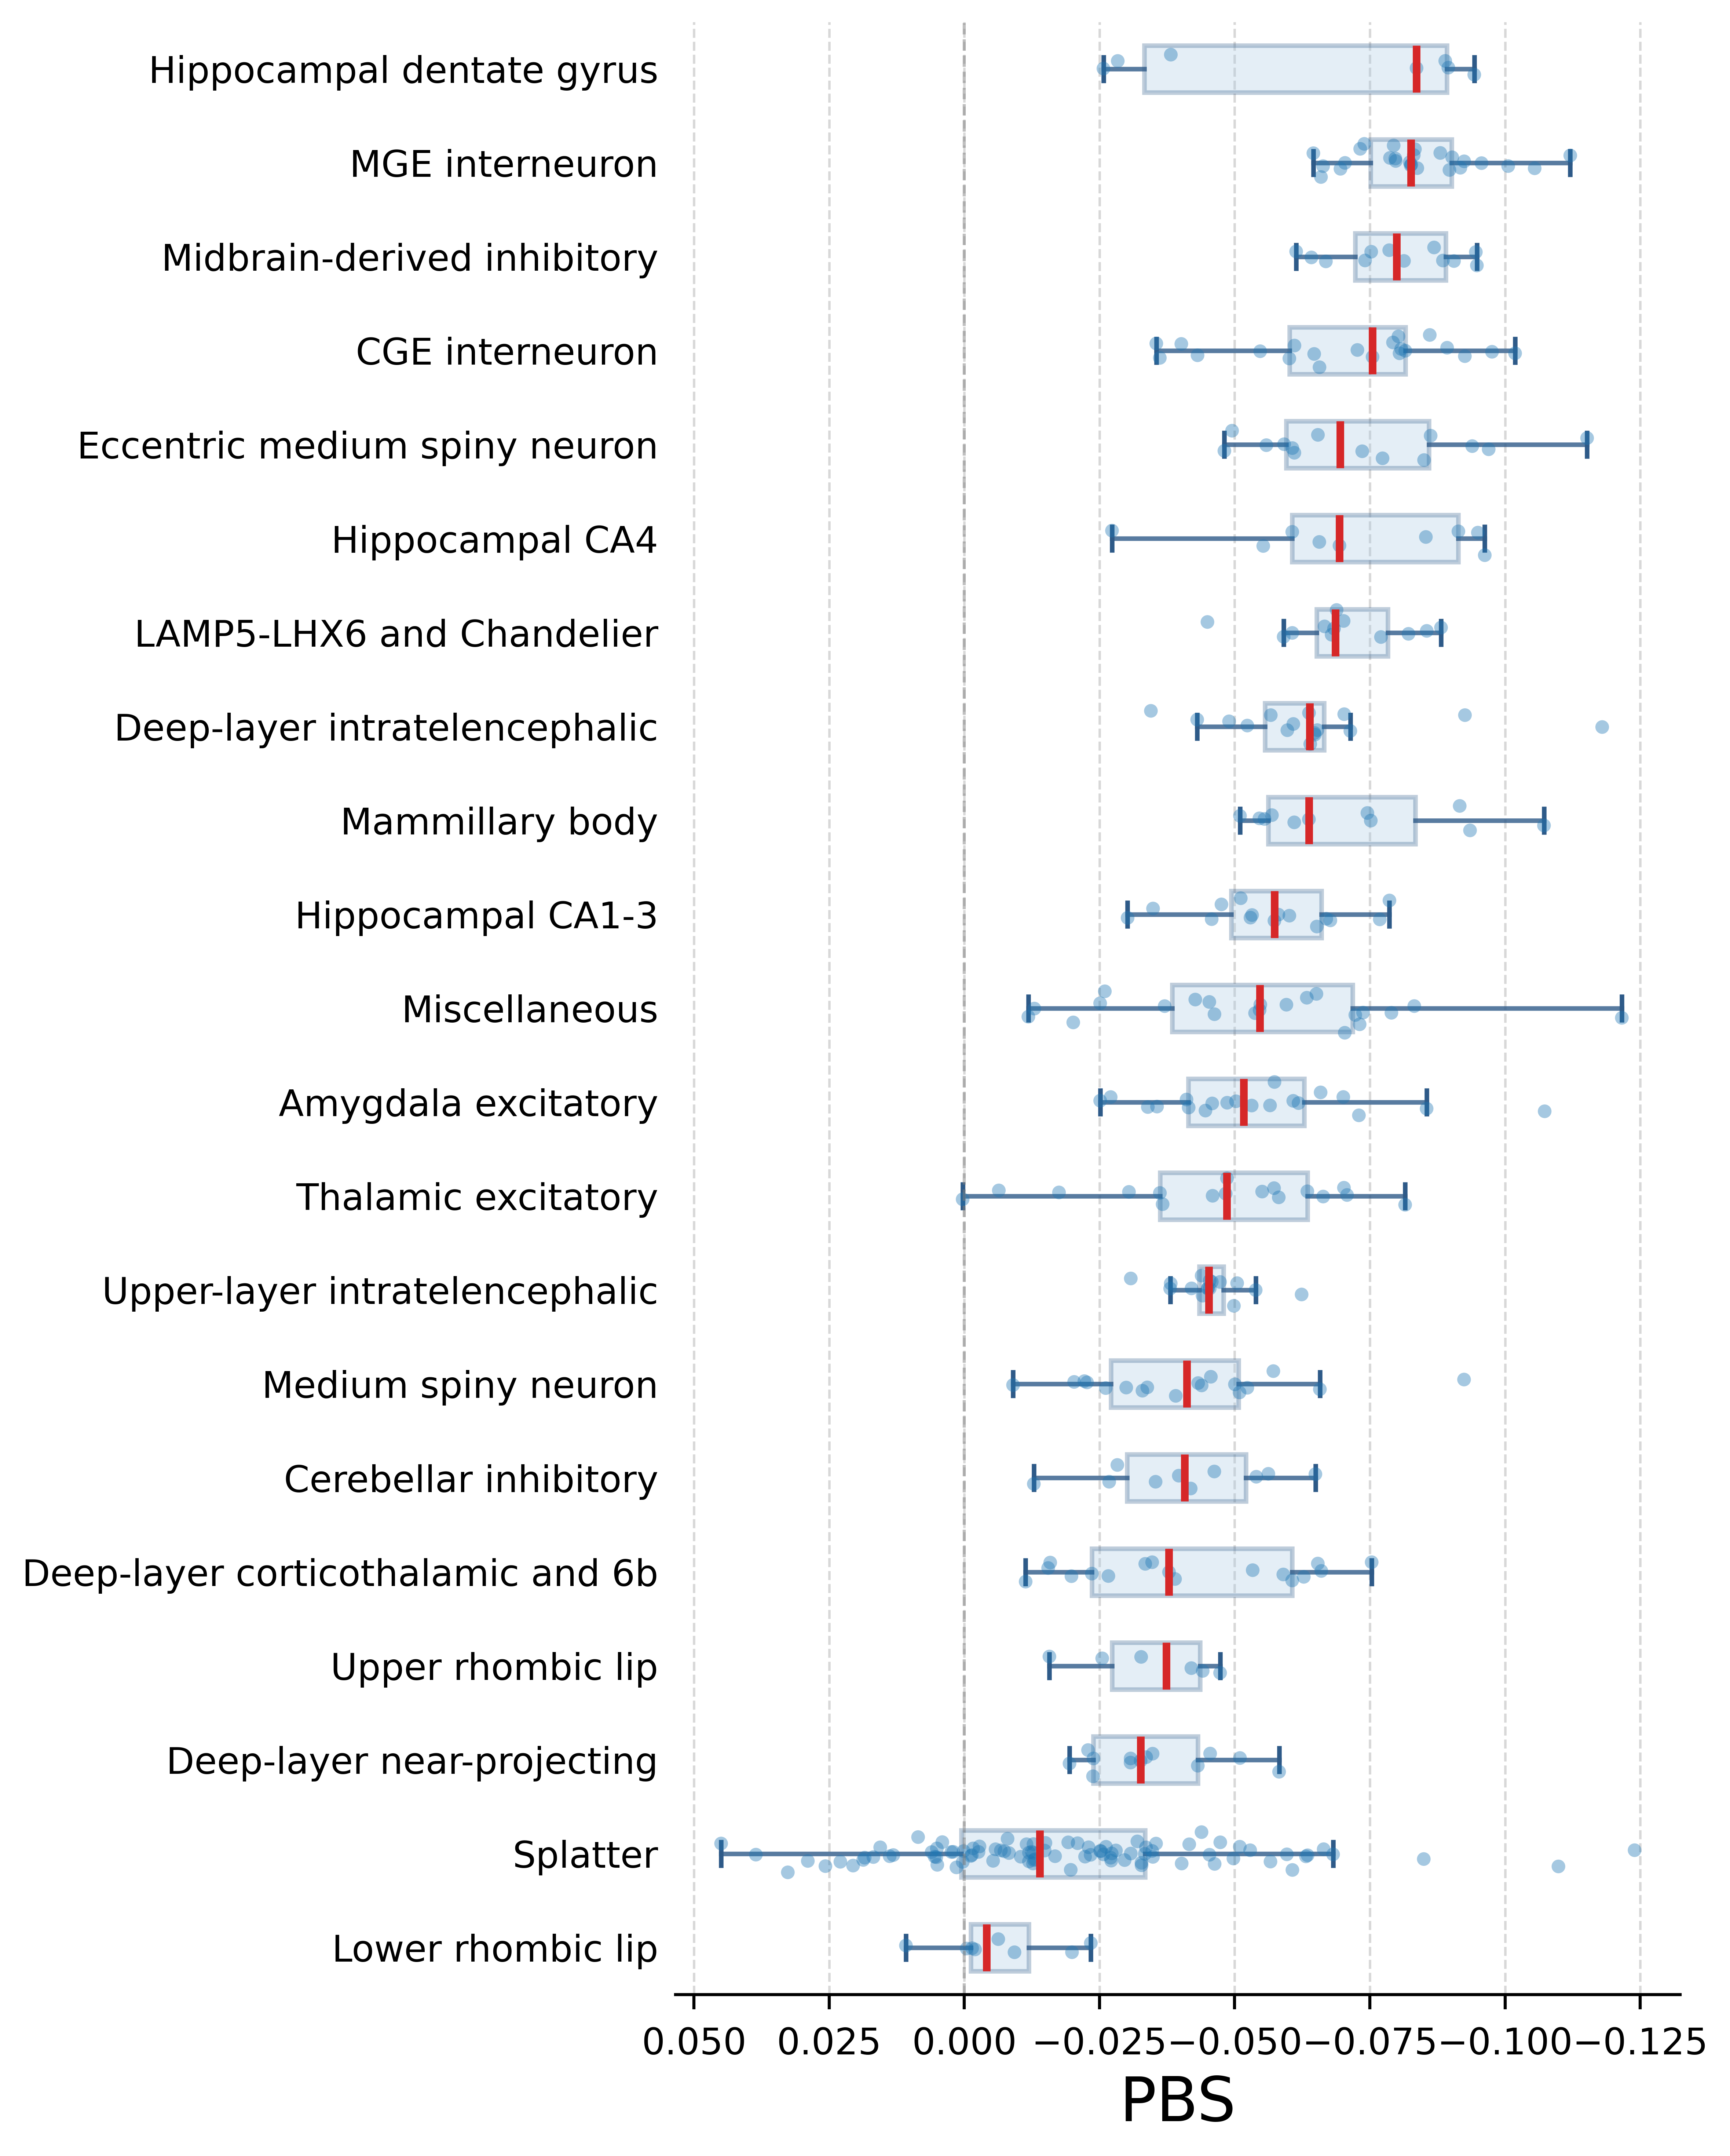

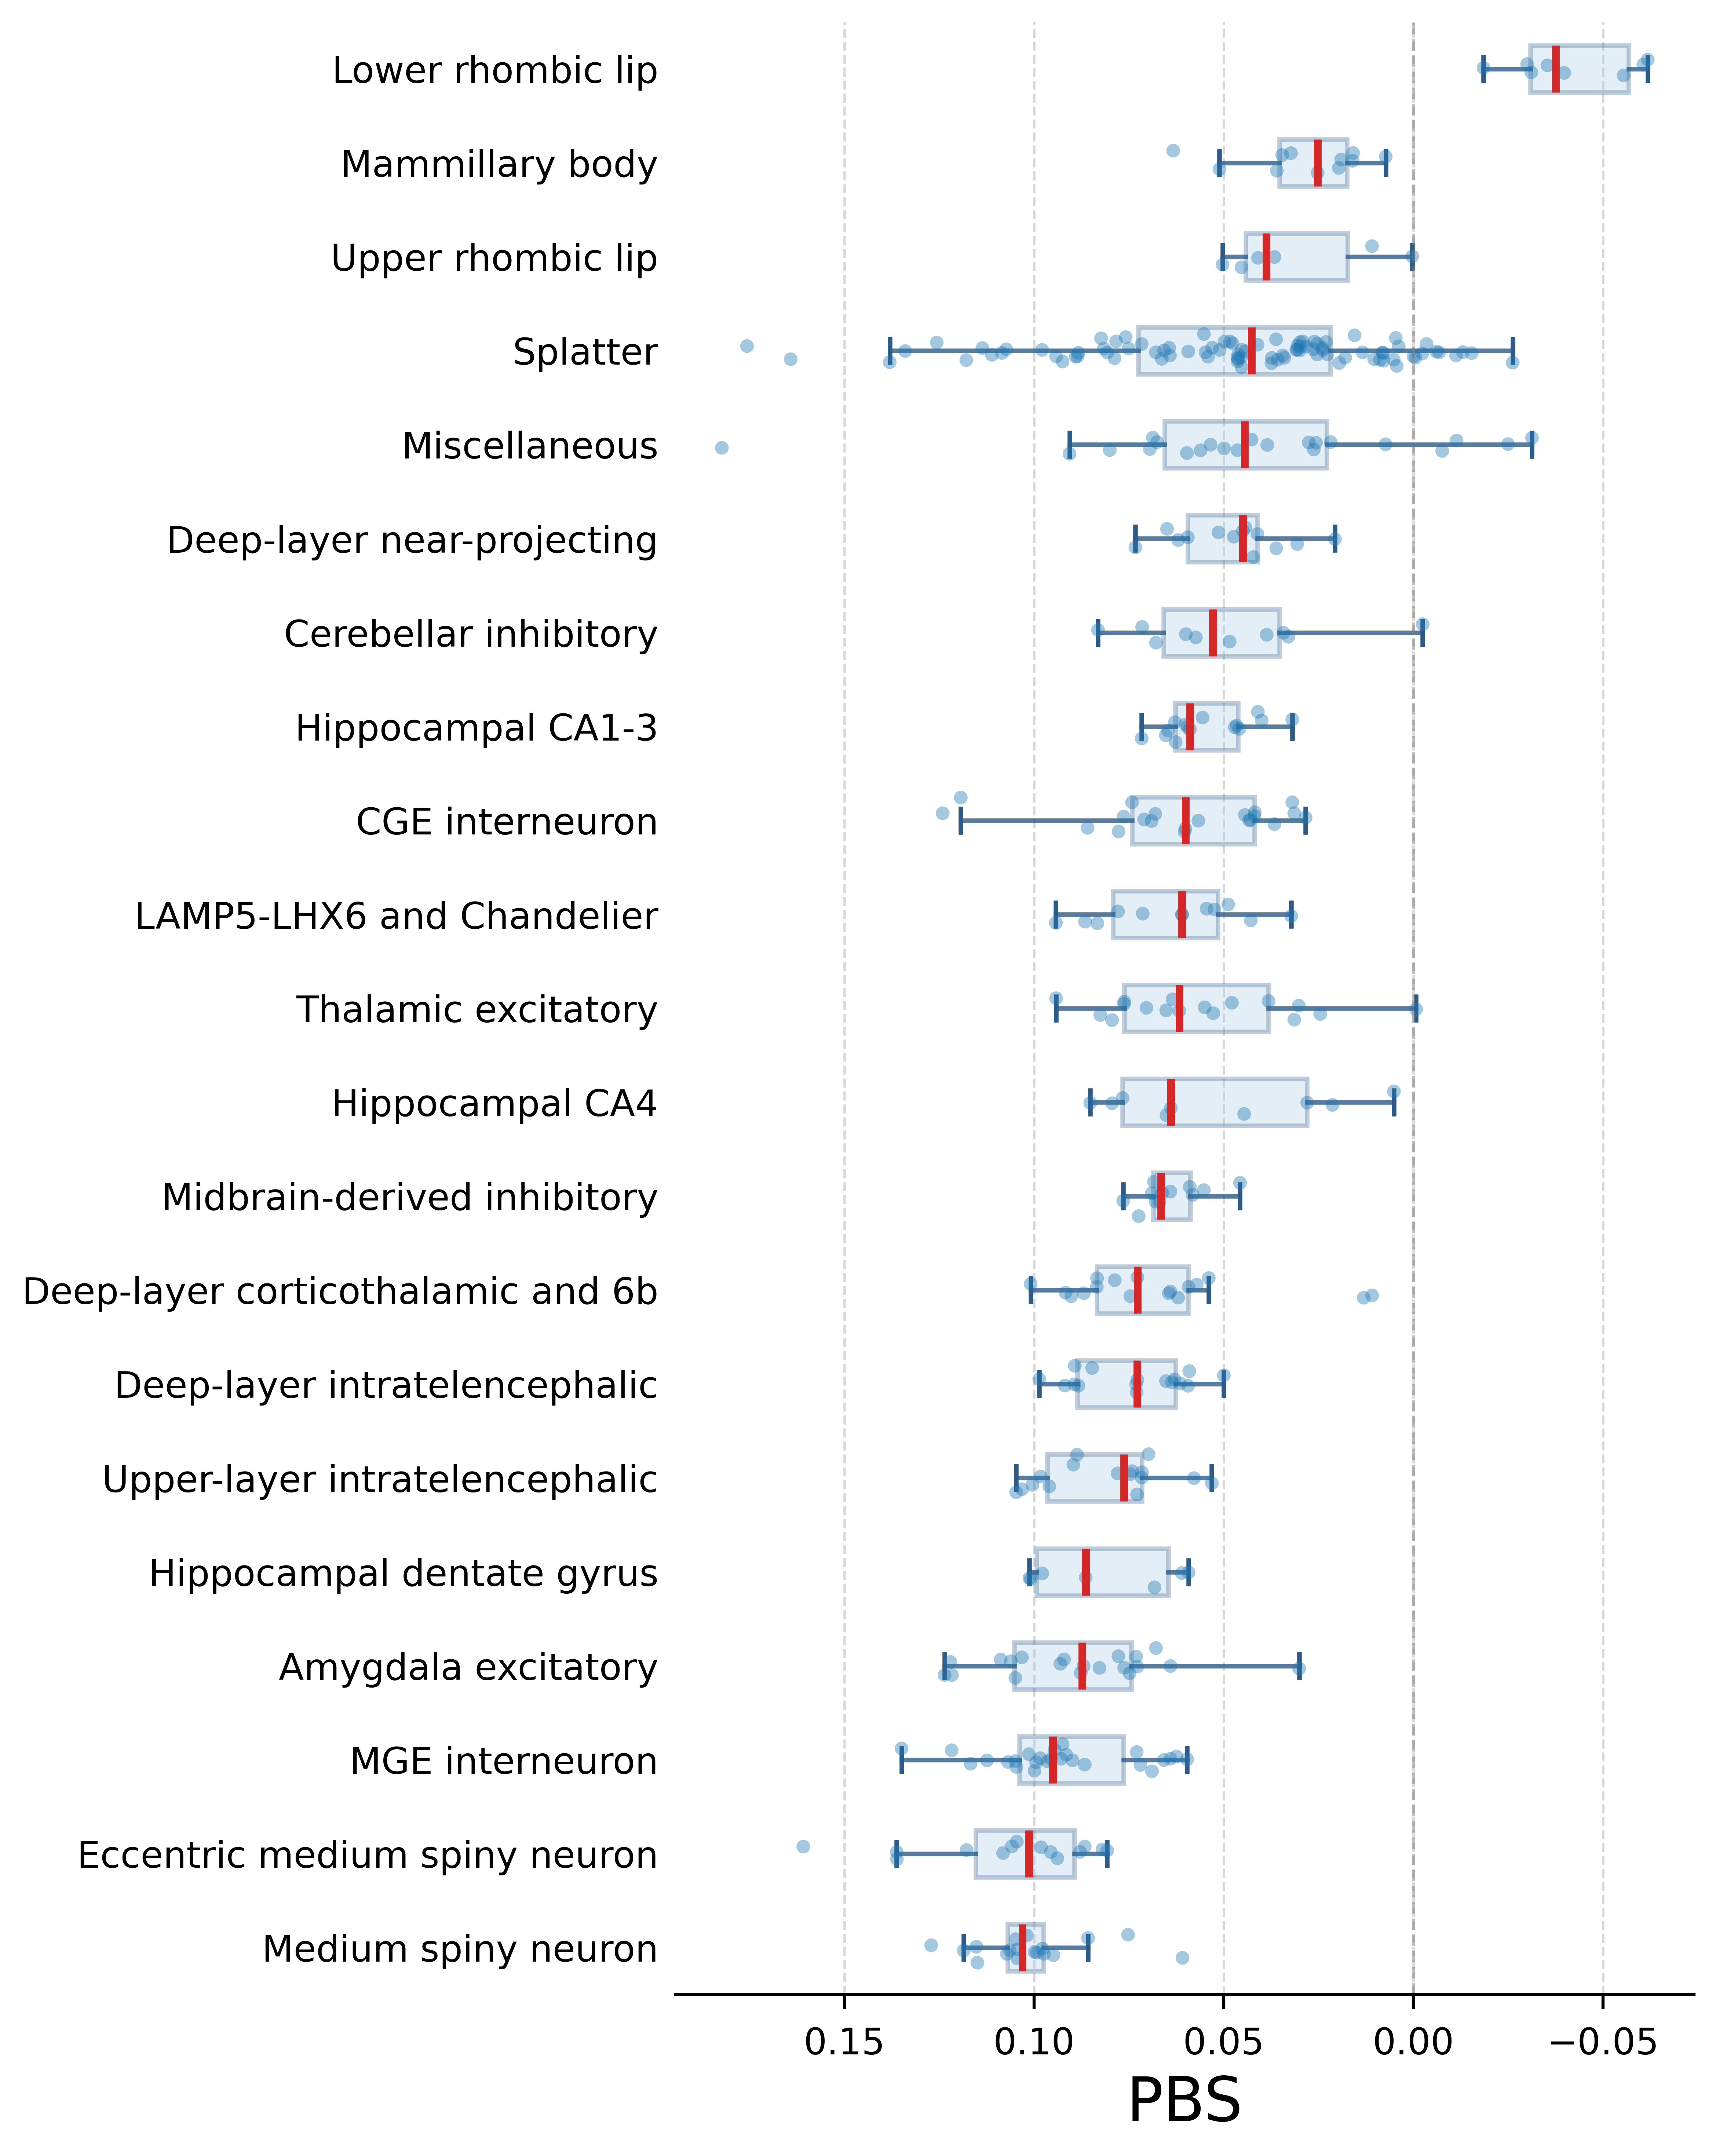

In [63]:
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_EDU, "EDU Spec", plot_metric="beta", sortby="median")
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_RT, "RT Spec", plot_metric="beta", sortby="median")

In [66]:
human_ct_df_EDU['-log10(p)'] = -np.log10(human_ct_df_EDU['p_value'])
human_ct_df_VNR['-log10(p)'] = -np.log10(human_ct_df_VNR['p_value'])
human_ct_df_RT['-log10(p)'] = -np.log10(human_ct_df_RT['p_value'])


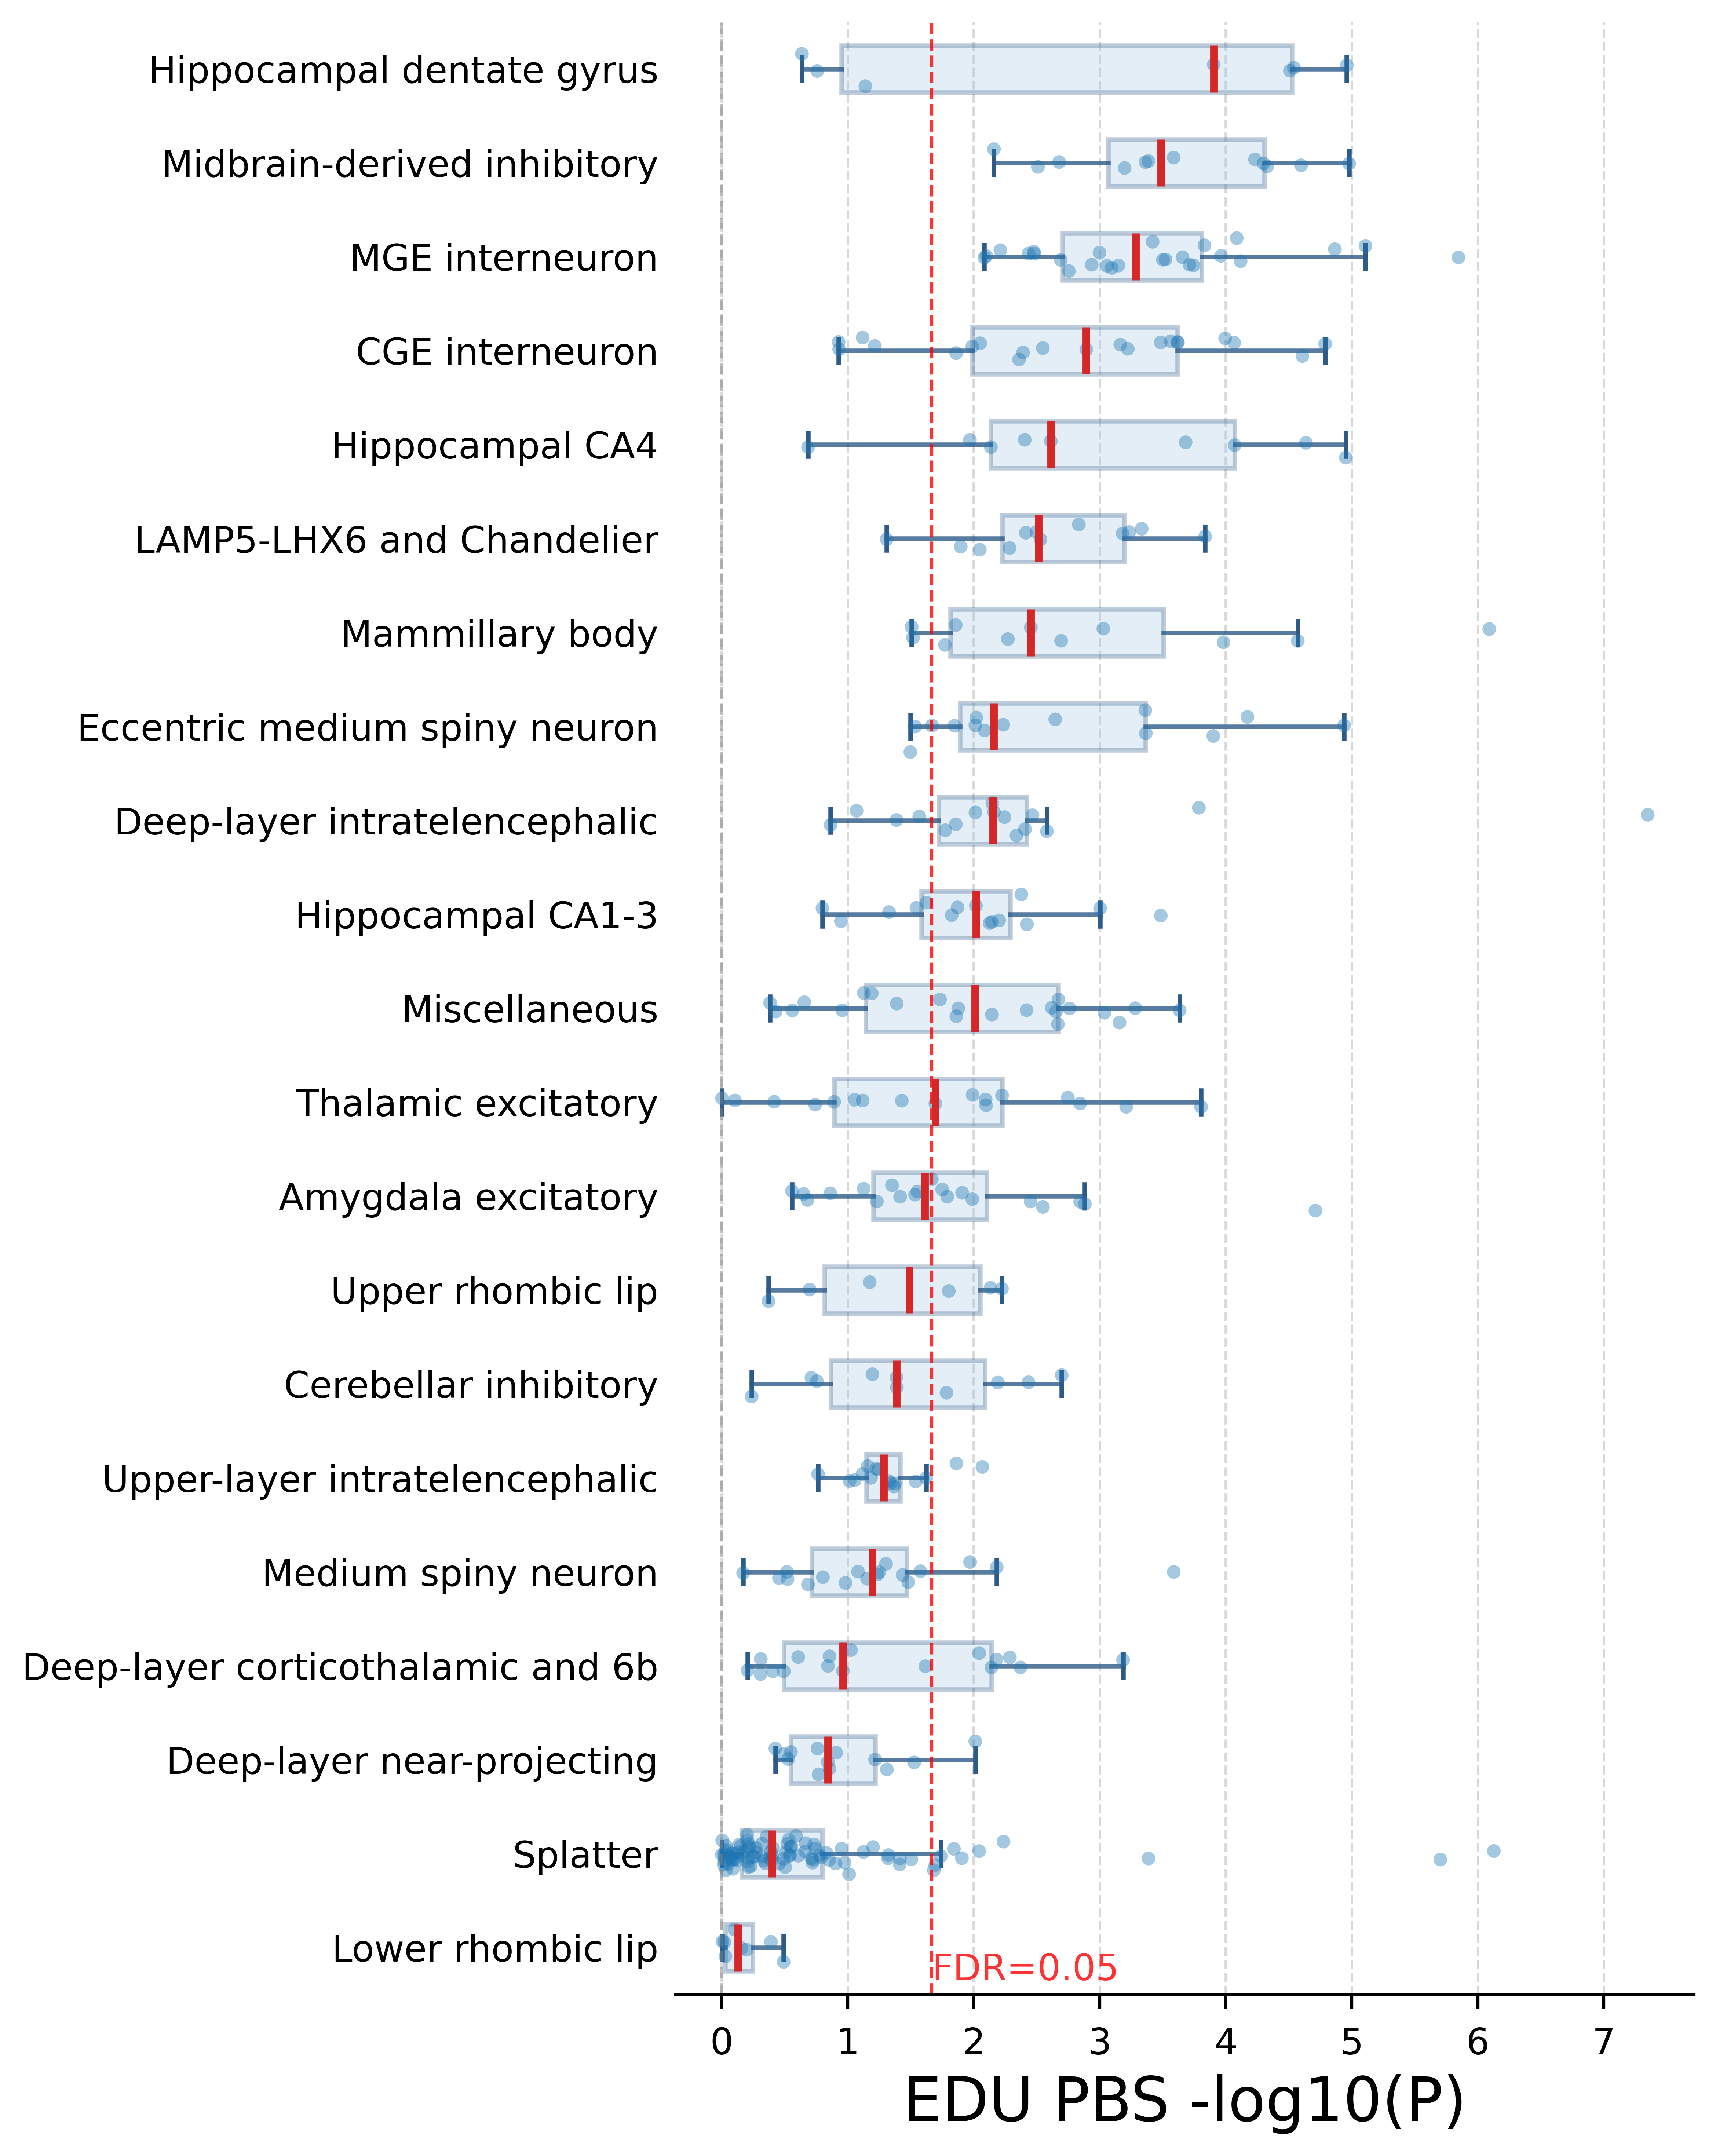

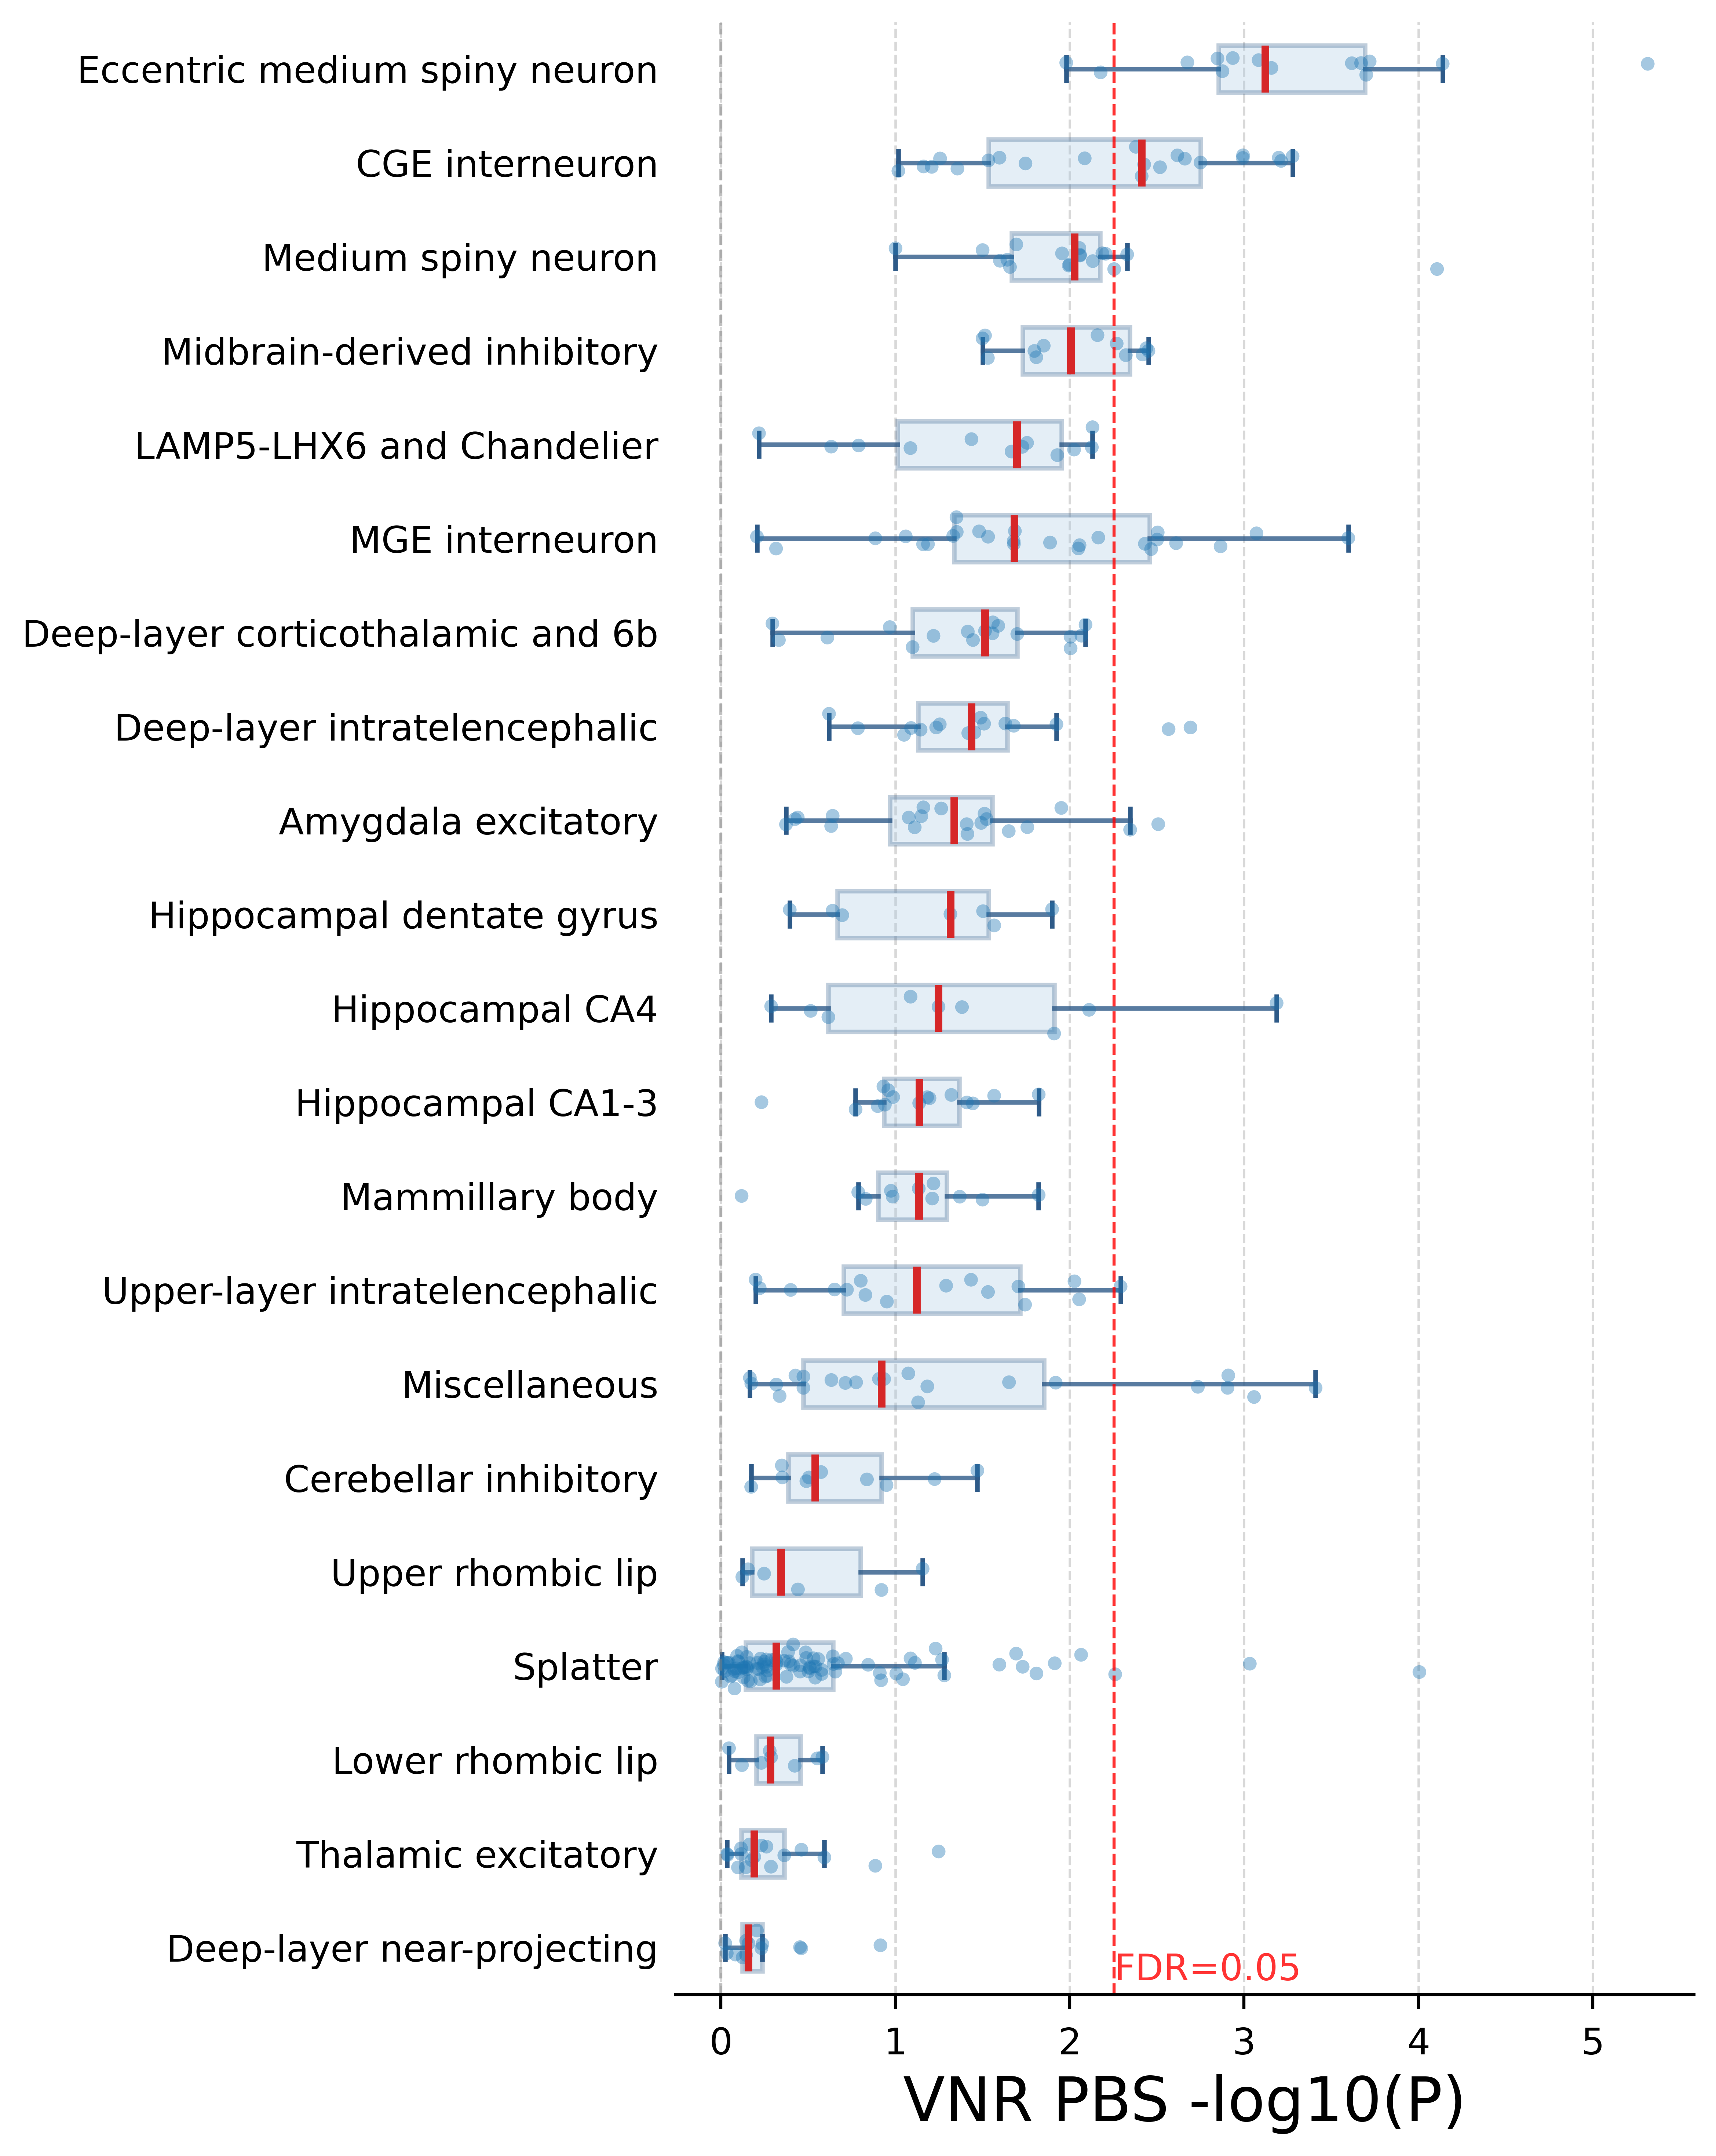

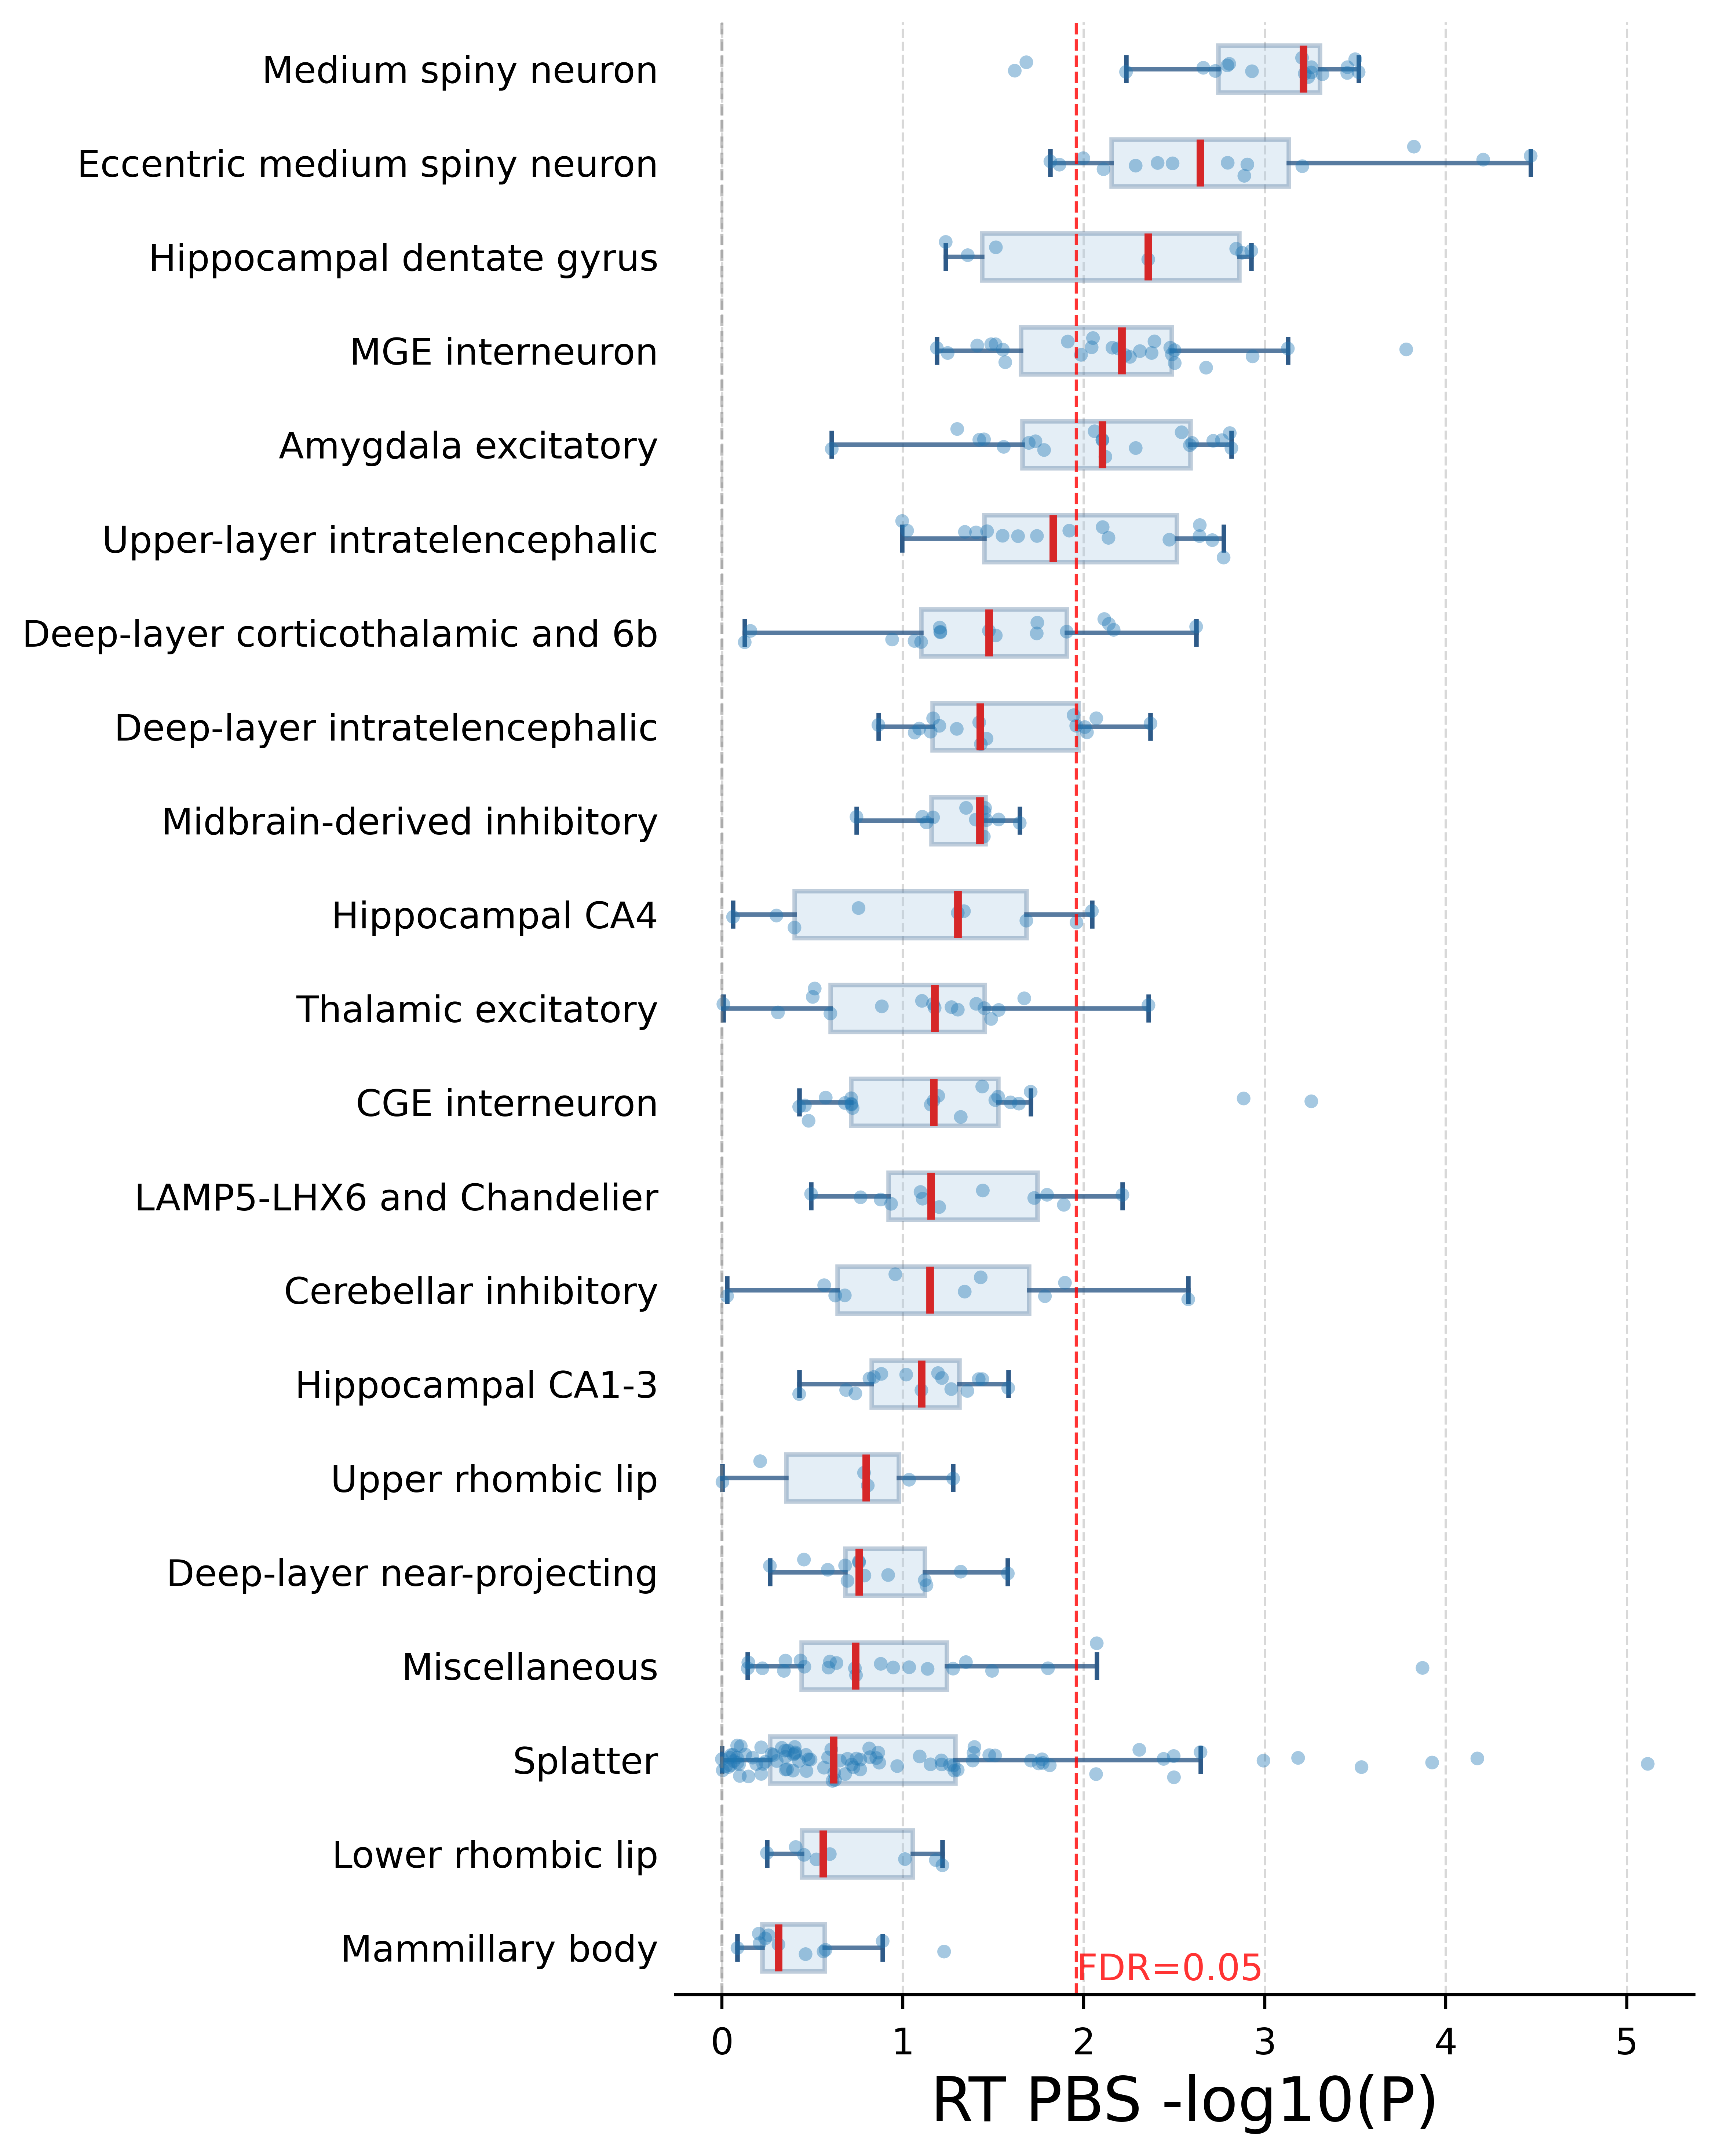

In [73]:
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_EDU, xlabel="EDU PBS -log10(P)", plot_metric="-log10(p)", sortby="median", flip_axis=False, FDR_label="FDR", Pval_label="-log10(p)")
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_VNR, xlabel="VNR PBS -log10(P)", plot_metric="-log10(p)", sortby="median", flip_axis=False, FDR_label="FDR", Pval_label="-log10(p)")
SuperClusterBias_BoxPlot_CorrIQ(human_ct_df_RT, xlabel="RT PBS -log10(P)", plot_metric="-log10(p)", sortby="median", flip_axis=False, FDR_label="FDR", Pval_label="-log10(p)")

In [64]:
human_ct_df_EDU.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,FDR
403,403,Splatter,-0.203741,4.475595e-09,-0.172424,7.461926e-07,-0.109879,-0.153119,-0.066640,-0.042181,0.029730,7.461926e-07,0.022028,0.000125
136,136,Deep-layer intratelencephalic,-0.203735,4.480501e-09,-0.190281,4.485911e-08,-0.117970,-0.159897,-0.076044,-0.043920,0.036207,4.485911e-08,0.021359,0.000021
242,242,MGE interneuron,-0.171207,8.947717e-07,-0.168053,1.423891e-06,-0.112066,-0.157348,-0.066784,-0.046379,0.028242,1.423891e-06,0.023069,0.000131
439,439,Midbrain-derived inhibitory,-0.166067,1.899323e-06,-0.140357,5.863227e-05,-0.086879,-0.129095,-0.044663,-0.066820,0.019700,5.863227e-05,0.021507,0.000932
280,280,CGE interneuron,-0.165721,1.996398e-06,-0.150475,1.624349e-05,-0.101862,-0.147962,-0.055763,-0.049614,0.022643,1.624349e-05,0.023485,0.000416
435,435,Midbrain-derived inhibitory,-0.165642,2.019449e-06,-0.153766,1.050320e-05,-0.094797,-0.136759,-0.052835,-0.063673,0.023644,1.050320e-05,0.021378,0.000354
296,296,CGE interneuron,-0.164318,2.441276e-06,-0.137226,8.575208e-05,-0.089289,-0.133686,-0.044892,-0.060184,0.018831,8.575208e-05,0.022618,0.001129
438,438,Midbrain-derived inhibitory,-0.162041,3.371694e-06,-0.141625,5.015714e-05,-0.088516,-0.131135,-0.045897,-0.067827,0.020058,5.015714e-05,0.021712,0.000826
437,437,Midbrain-derived inhibitory,-0.159205,5.009361e-06,-0.147066,2.527117e-05,-0.094602,-0.138431,-0.050773,-0.064156,0.021628,2.527117e-05,0.022329,0.000526
282,282,CGE interneuron,-0.158119,5.819228e-06,-0.147258,2.465394e-05,-0.092572,-0.135403,-0.049741,-0.056111,0.021685,2.465394e-05,0.021820,0.000526


In [65]:
def CleanUpUKBBPheno(DF):
    res = DF.copy(deep=True)
    res = res[["CT", "Supercluster", "beta", "CI_low", "CI_high", "p_value", "FDR", "r_value"]]
    res = res.rename(columns={"CT": "Cluster", "Supercluster": "SuperCluster"})
    return res

In [66]:
human_ct_df_EDU_clean = CleanUpUKBBPheno(human_ct_df_EDU)
human_ct_df_VNR_clean = CleanUpUKBBPheno(human_ct_df_VNR)
human_ct_df_RT_clean = CleanUpUKBBPheno(human_ct_df_RT)
human_ct_df_EDU_clean.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.EDU.csv")
human_ct_df_VNR_clean.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.VNR.csv")
human_ct_df_RT_clean.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.RT.csv")

In [67]:
VIP_Anno = pd.read_csv("VIP_Anno.csv", index_col=0)

In [68]:
common_indices = human_ct_df_VNR_clean.index.intersection(VIP_Anno.index)
human_ct_df_VNR_clean_sub = human_ct_df_VNR_clean.loc[common_indices].copy()
human_ct_df_VNR_clean_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

/tmp/ipykernel_4096176/3146972169.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["VIP+", "VIP-"])


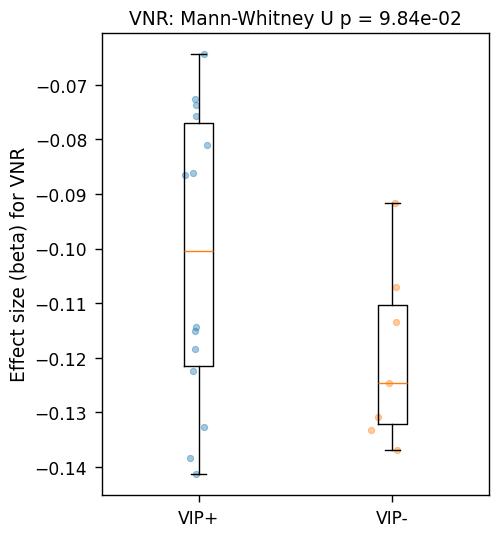

In [76]:
# Adjust code for VNR
common_indices = human_ct_df_VNR_clean.index.intersection(VIP_Anno.index)
human_ct_df_VNR_clean_sub = human_ct_df_VNR_clean.loc[common_indices].copy()
human_ct_df_VNR_clean_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

# Filter for VNR phenotype
VNR_df = human_ct_df_VNR_clean_sub.copy()

# Split into VIP+ and VIP- groups
VNR_VIP_pos = VNR_df[VNR_df["VIP"] >= 1]
VNR_VIP_neg = VNR_df[VNR_df["VIP"] < 1]

# Prepare data for plotting
data = [VNR_VIP_pos["beta"], VNR_VIP_neg["beta"]]
from scipy.stats import mannwhitneyu

stat, pval = mannwhitneyu(VNR_VIP_pos["beta"], VNR_VIP_neg["beta"], alternative="greater")

# Boxplot with scatter
plt.figure(figsize=(5, 6))
plt.boxplot(data, labels=["VIP+", "VIP-"])
for i, d in enumerate(data):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect size (beta) for VNR")
plt.title(f"VNR: Mann-Whitney U p = {pval:.2e}")
plt.show()


/tmp/ipykernel_4096176/423688072.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["VIP+", "VIP-"])


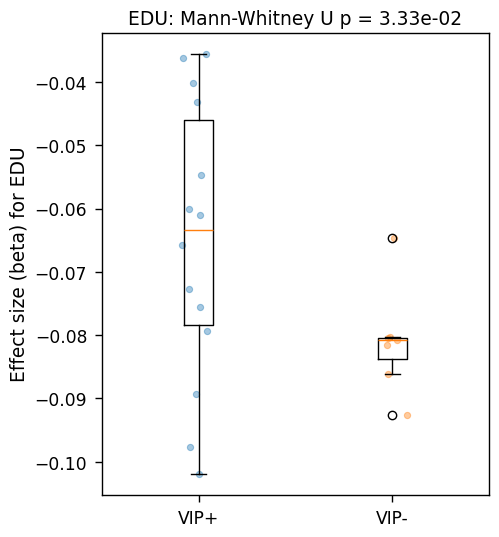

In [75]:
# Adjust code for EDU
common_indices = human_ct_df_EDU_clean.index.intersection(VIP_Anno.index)
human_ct_df_EDU_clean_sub = human_ct_df_EDU_clean.loc[common_indices].copy()
human_ct_df_EDU_clean_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

# Filter for EDU phenotype
EDU_df = human_ct_df_EDU_clean_sub.copy()

# Split into VIP+ and VIP- groups
EDU_VIP_pos = EDU_df[EDU_df["VIP"] >= 1]
EDU_VIP_neg = EDU_df[EDU_df["VIP"] < 1]

# Prepare data for plotting
data = [EDU_VIP_pos["beta"], EDU_VIP_neg["beta"]]

stat, pval = mannwhitneyu(EDU_VIP_pos["beta"], EDU_VIP_neg["beta"], alternative="greater")

# Boxplot with scatter
plt.figure(figsize=(5, 6))
plt.boxplot(data, labels=["VIP+", "VIP-"])
for i, d in enumerate(data):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect size (beta) for EDU")
plt.title(f"EDU: Mann-Whitney U p = {pval:.2e}")
plt.show()


/tmp/ipykernel_4096176/2680479397.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["VIP+", "VIP-"])


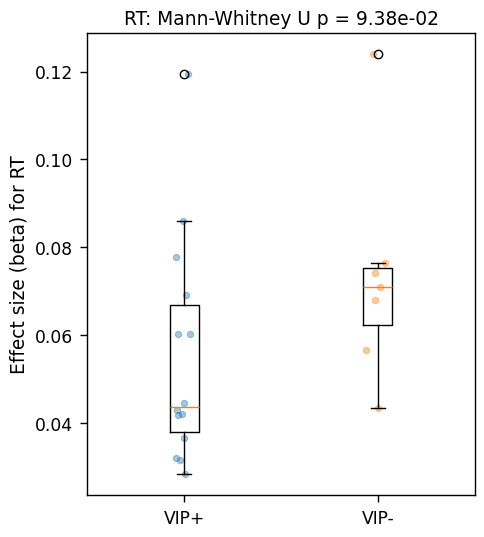

In [74]:
# Adjust code for RT (Reaction Time)
common_indices = human_ct_df_RT_clean.index.intersection(VIP_Anno.index)
human_ct_df_RT_clean_sub = human_ct_df_RT_clean.loc[common_indices].copy()
human_ct_df_RT_clean_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

# Filter for RT phenotype
RT_df = human_ct_df_RT_clean_sub.copy()

# Split into VIP+ and VIP- groups
RT_VIP_pos = RT_df[RT_df["VIP"] >= 1]
RT_VIP_neg = RT_df[RT_df["VIP"] < 1]

# Prepare data for plotting
data = [RT_VIP_pos["beta"], RT_VIP_neg["beta"]]

stat, pval = mannwhitneyu(RT_VIP_pos["beta"], RT_VIP_neg["beta"])

# Boxplot with scatter
plt.figure(figsize=(5, 6))
plt.boxplot(data, labels=["VIP+", "VIP-"])
for i, d in enumerate(data):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect size (beta) for RT")
plt.title(f"RT: Mann-Whitney U p = {pval:.2e}")
plt.show()
